# Cierre técnico del proyecto — Fase 4

**Exploración inteligente para la Ciencia de Datos (MCDI503)**

---
## I. Encabezado e identificación del notebook

**Título del cierre:** Pipeline exploratorio reproducible de ingeniería de variables y selección preliminar de características — dataset Titanic

**Integrantes del equipo (Grupo 5):**
- Arturo Knopke Vera
- Nicolás Soletic Cobos
- Sebastián Navarrete Soto
- Roberto Moncada González

**Dataset utilizado:** el dataset preparado equivalente a `data/titanic_prepared.csv` (891 registros, 32 columnas), reconstruido en la sección II.2 a partir del dataset original leído **directamente desde internet** (fuente principal disponible públicamente en GitHub, equivalente en contenido de datos a `Titanic-Dataset.csv` de Kaggle utilizado en las Fases 1 y 2-3) integrado con la fuente complementaria `seaborn`-data (leída también desde su URL pública, la misma que consulta internamente `seaborn.load_dataset("titanic")`). Este notebook **no depende de archivos locales en `data/` ni de que se ejecute desde una carpeta específica del repositorio**: reproduce de forma condensada, en la sección II.2, la limpieza, imputación, integración y transformaciones ya validadas en las Fases 1 y 2-3 (ver `mcdi503_f1_sumativo_grupo5.ipynb` y `mcdi503_f23_sumativo_grupo5.ipynb`, que documentan el detalle narrativo, el diagnóstico de calidad y el análisis exploratorio completos de esas fases); valida además, en la sección II.1, las versiones mínimas de librerías necesarias; y, a partir de ese punto, desarrolla el pipeline propio de la Fase 4, escribiendo sus salidas en el directorio de trabajo actual.

**Propósito general del notebook:** cerrar el proyecto construyendo un pipeline exploratorio reproducible que:
1. aplique transformaciones y normalizaciones **nuevas**, justificadas en hallazgos concretos de las fases anteriores;
2. diseñe un número acotado de variables derivadas con valor analítico explícito, evitando sobre-ingeniería;
3. seleccione preliminarmente las características más pertinentes para una etapa posterior de modelamiento, usando criterios explícitos (relevancia, redundancia, interpretabilidad, consistencia y utilidad predictiva potencial medida con evidencia estadística, sin entrenar modelos predictivos en esta fase);
4. deje documentada, de forma trazable, cada decisión y su efecto en los datos.

> **Nota de alcance (RA4):** el objetivo de esta fase es dejar el dataset preparado y justificado para una etapa **posterior** de modelamiento, no construir ni evaluar un modelo predictivo final.

---
## II. Carga de datos y preparación del entorno

Se importan las librerías necesarias. Además de `pandas`, `numpy`, `matplotlib`, `seaborn` y `scipy.stats` (ya usadas en fases anteriores), esta fase incorpora utilidades de `scikit-learn`:
- `RobustScaler` (y `StandardScaler`, solo como comparación en el diagnóstico de la sección VIII), para el escalado de variables numéricas (sección IV);
- `mutual_info_classif`, como medida no paramétrica de relevancia respecto de `Survived` (sección VI);
- `LabelEncoder`, solo para codificar categorías como enteros al estimar la información mutua;
- `LogisticRegression`, usada únicamente como herramienta para calcular verosimilitudes en el test de razón de verosimilitudes de la interacción (sección V.2). **No se entrena ni se evalúa ningún modelo predictivo.**

Se fija una semilla aleatoria (`RANDOM_STATE`) para que cualquier cálculo con componente aleatorio (p. ej. la estimación de `mutual_info_classif`, que añade ruido para variables continuas) sea reproducible. `RUTA_FIGURAS` (`"."`) y `RUTA_SALIDA` (`"titanic_features.csv"`) no asumen un directorio de trabajo fijo: apuntan al **directorio actual** desde el que se lance el notebook, que es también donde se escriben las figuras y el dataset final. También se definen aquí las URLs públicas de las dos fuentes de datos —`RUTA_DATOS_URL` (dataset principal) y `RUTA_DATOS_WEB_URL` (fuente complementaria `seaborn`-data)— que se usan en la sección II.2 para reconstruir en memoria, leyendo solo desde internet, el equivalente a `titanic_prepared.csv` antes de continuar con el resto del pipeline. La sección II.1, a continuación, verifica que las librerías instaladas cumplan las versiones mínimas requeridas.

In [1]:
import io
import importlib.metadata as metadatos_paquetes
import re
import unicodedata
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, RobustScaler, StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 130)

RANDOM_STATE = 42
SEMILLAS_MI = list(range(20)) + [RANDOM_STATE]  # semillas para comprobar la estabilidad de la información mutua
RUTA_DATOS_URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
RUTA_DATOS_WEB_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
RUTA_FIGURAS = "."  # directorio actual: se ejecuta y escribe donde se lance el notebook
RUTA_SALIDA = "titanic_features.csv"

---
### II.1 Verificación de versiones mínimas de librerías

Antes de continuar, se valida que las librerías instaladas cumplan las versiones mínimas con las que este notebook fue desarrollado y validado (las mismas cotas de `requirements.txt`). Si alguna versión no se cumple, la celda siguiente **detiene la ejecución** con un error explícito que indica qué librería(s) actualizar, en lugar de continuar y arriesgar un resultado inválido o difícil de diagnosticar más adelante (p. ej. por cambios de comportamiento entre versiones de `pandas`, `numpy` o `scikit-learn`).

In [2]:
REQUISITOS_MINIMOS = {
    "pandas": "3.0",
    "numpy": "2.0",
    "matplotlib": "3.10",
    "seaborn": "0.13",
    "scipy": "1.15",
    "scikit-learn": "1.5",
}


def version_a_tupla(version_texto):
    partes = []
    for parte in version_texto.split(".")[:3]:
        digitos = ""
        for caracter in parte:
            if caracter.isdigit():
                digitos += caracter
            else:
                break
        partes.append(int(digitos) if digitos else 0)
    while len(partes) < 3:
        partes.append(0)
    return tuple(partes)


problemas_version = []
versiones_instaladas = {}
for paquete, minima in REQUISITOS_MINIMOS.items():
    try:
        instalada = metadatos_paquetes.version(paquete)
    except metadatos_paquetes.PackageNotFoundError:
        problemas_version.append(f"{paquete}: no está instalado (se requiere >= {minima})")
        continue
    versiones_instaladas[paquete] = instalada
    if version_a_tupla(instalada) < version_a_tupla(minima):
        problemas_version.append(f"{paquete}: instalada {instalada}, se requiere >= {minima}")

if problemas_version:
    raise RuntimeError(
        "Este notebook requiere versiones mínimas de librerías que no se cumplen:\n- "
        + "\n- ".join(problemas_version)
        + "\n\nActualice el entorno con: pip install -r requirements.txt"
    )

print("Verificación de versiones de librerías: OK")
for paquete, minima in REQUISITOS_MINIMOS.items():
    print(f"  {paquete:<14} {versiones_instaladas[paquete]:<10} (mínimo requerido: {minima})")

Verificación de versiones de librerías: OK
  pandas         3.0.5      (mínimo requerido: 3.0)
  numpy          2.5.3      (mínimo requerido: 2.0)
  matplotlib     3.11.2     (mínimo requerido: 3.10)
  seaborn        0.13.2     (mínimo requerido: 0.13)
  scipy          1.18.1     (mínimo requerido: 1.15)
  scikit-learn   1.9.1      (mínimo requerido: 1.5)


---
### II.2 Reproducción condensada de las Fases 1 y 2-3 (carga desde internet, limpieza, integración y transformación)

Para que este notebook se pueda ejecutar de principio a fin leyendo **únicamente el dataset original desde internet** (sin depender de `../data/Titanic-Dataset.csv`, `../data/titanic_seaborn_reference.csv` ni `../data/titanic_prepared.csv`), se reconstruye aquí, de forma condensada, el pipeline de datos ya validado en `mcdi503_f1_sumativo_grupo5.ipynb` y `mcdi503_f23_sumativo_grupo5.ipynb`:

1. **Carga desde internet** de la fuente principal (fuente principal disponible públicamente en GitHub, equivalente en contenido de datos a la utilizada en las Fases 1 y 2-3) y de la fuente complementaria `seaborn`-data (la misma URL que consulta internamente `seaborn.load_dataset("titanic")`).
2. **Limpieza e imputación definitiva** de `Embarked` (moda) y `Age` (mediana estratificada por `Pclass × Sex`, validada con la prueba de Kruskal-Wallis), y tratamiento de `Cabin` mediante indicador y letra de cubierta — Fase 2-3, apartado V.1.
3. **Validación de alineación e integración** con la fuente complementaria — Fase 2-3, apartado V.2.
4. **Transformaciones** (`Sex_bin`, `Title`/`Title_agrupado`, `FamilySize`/`IsAlone`, `AgeGroup`, `Fare_log`/`FareBand`, `Deck_combinado`, tipado categórico) — Fase 2-3, apartado VI.

El código de esta subsección reproduce literalmente el de esas fases (mismas decisiones, mismos parámetros, mismo criterio de imputación e integración); no se repiten aquí el diagnóstico de calidad, el análisis univariado/bivariado ni las visualizaciones exploratorias de F1 y F23, que se documentan con su detalle narrativo completo en esos notebooks. Al final de esta subsección, `df` se serializa a CSV y se vuelve a leer en memoria (sin tocar el disco) para replicar exactamente el efecto del ciclo `to_csv`/`read_csv` entre las Fases 2-3 y la Fase 4 (p. ej., la pérdida del dtype `category` al pasar por CSV), de modo que el resto del notebook reciba un `df` idéntico al que se obtendría al leer `titanic_prepared.csv` desde disco.

In [3]:
# Carga desde internet de ambas fuentes (equivalente a F1/F23, sin depender de archivos locales)
titanic = pd.read_csv(RUTA_DATOS_URL)
titanic_web = pd.read_csv(RUTA_DATOS_WEB_URL)
print("Fuente principal (F1/F23, vía internet) — dimensiones:", titanic.shape)
print("Fuente complementaria seaborn-data (F23, vía internet) — dimensiones:", titanic_web.shape)

Fuente principal (F1/F23, vía internet) — dimensiones: (891, 12)
Fuente complementaria seaborn-data (F23, vía internet) — dimensiones: (891, 15)


In [4]:
# Limpieza y validación de la fuente principal (F23, apartado V.1)
titanic_clean = titanic.copy()

# (a) Duplicados: no se detectaron filas duplicadas (ver F23, apartado IV); se documenta el criterio igualmente
titanic_clean = titanic_clean.drop_duplicates()
assert titanic_clean["PassengerId"].is_unique, "PassengerId debería ser único"

# (b) Embarked: imputación puntual definitiva con la moda (2 casos, 0.22% del total)
moda_embarked = titanic_clean["Embarked"].mode(dropna=True).iloc[0]
titanic_clean["Embarked_clean"] = titanic_clean["Embarked"].fillna(moda_embarked)
print(f"Embarked: {titanic_clean['Embarked'].isna().sum()} valores faltantes imputados con la moda ('{moda_embarked}')")

# (c) Age: imputación definitiva estratificada por Pclass x Sex, validada con Kruskal-Wallis (F23, apartado V.1)
grupos_edad = [g["Age"].dropna().values for _, g in titanic_clean.groupby(["Pclass", "Sex"]) if g["Age"].notna().sum() > 0]
h_stat, p_valor_kw = stats.kruskal(*grupos_edad)
print(f"Kruskal-Wallis Age ~ Pclass x Sex: H={h_stat:.2f}, p-valor={p_valor_kw:.2e}")

titanic_clean["Age_registrada"] = titanic_clean["Age"].notna().astype(int)
mediana_edad_grupo = titanic_clean.groupby(["Pclass", "Sex"])["Age"].transform("median")
mediana_global = titanic_clean["Age"].median()
titanic_clean["Age_clean"] = titanic_clean["Age"].fillna(mediana_edad_grupo).fillna(mediana_global)
print(f"Age: {titanic_clean['Age'].isna().sum()} valores faltantes imputados con la mediana de su grupo Pclass x Sex")

# (d) Cabin: no se imputa el camarote específico (77.1% de faltantes); se conserva un indicador y la letra de cubierta
titanic_clean["Cabin_registrada"] = titanic_clean["Cabin"].notna().astype(int)
titanic_clean["Cabin_letra"] = titanic_clean["Cabin"].str[0]

Embarked: 2 valores faltantes imputados con la moda ('S')
Kruskal-Wallis Age ~ Pclass x Sex: H=112.28, p-valor=1.35e-22
Age: 177 valores faltantes imputados con la mediana de su grupo Pclass x Sex


In [5]:
# Validación de alineación registro a registro con la fuente complementaria (F23, apartado V.2):
# sin llave explícita común, se comprueba que ambas fuentes están ordenadas de forma idéntica
# antes de integrarlas por posición.
comparaciones = {
    "Pclass == pclass": (titanic["Pclass"].values == titanic_web["pclass"].values).mean(),
    "Sex == sex": (titanic["Sex"].values == titanic_web["sex"].values).mean(),
    "SibSp == sibsp": (titanic["SibSp"].values == titanic_web["sibsp"].values).mean(),
    "Parch == parch": (titanic["Parch"].values == titanic_web["parch"].values).mean(),
    "Survived == survived": (titanic["Survived"].values == titanic_web["survived"].values).mean(),
    "Fare == fare": np.isclose(titanic["Fare"].values, titanic_web["fare"].values, atol=1e-3).mean(),
    "Age == age (incl. NaN==NaN)": np.equal(
        np.isnan(titanic["Age"].values), np.isnan(titanic_web["age"].values)
    ).mean() * np.isclose(
        titanic["Age"].fillna(-1).values, titanic_web["age"].fillna(-1).values, atol=1e-6
    ).mean(),
}
assert all(v == 1.0 for v in comparaciones.values()), "Las fuentes no están alineadas registro a registro; no es seguro integrarlas por posición"
print("Validación de alineación registro a registro:", comparaciones)

# Integración: se incorporan las variables no presentes en la fuente principal (F23, apartado V.2)
columnas_a_integrar = ["class", "who", "adult_male", "deck", "embark_town", "alone"]
titanic_int = titanic_clean.reset_index(drop=True).join(titanic_web[columnas_a_integrar].reset_index(drop=True))
print("Dimensiones tras la integración:", titanic_int.shape)

Validación de alineación registro a registro: {'Pclass == pclass': np.float64(1.0), 'Sex == sex': np.float64(1.0), 'SibSp == sibsp': np.float64(1.0), 'Parch == parch': np.float64(1.0), 'Survived == survived': np.float64(1.0), 'Fare == fare': np.float64(1.0), 'Age == age (incl. NaN==NaN)': np.float64(1.0)}
Dimensiones tras la integración: (891, 23)


In [6]:
# Transformaciones aplicadas y preparación del dataset (F23, apartado VI)
df = titanic_int.copy()

# (1) Sex a formato binario numérico, conservando la versión categórica
df["Sex_bin"] = df["Sex"].map({"male": 0, "female": 1})

# (2) Título extraído del nombre, agrupado en categorías con criterio sociodemográfico explícito
df["Title"] = df["Name"].str.extract(r",\s*([^\.]+)\.")[0].str.strip()

mapa_titulos = {
    "Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs",
    "Dr": "Oficial_Profesional", "Rev": "Oficial_Profesional", "Col": "Oficial_Profesional",
    "Major": "Oficial_Profesional", "Capt": "Oficial_Profesional",
    "Lady": "Nobleza", "the Countess": "Nobleza", "Sir": "Nobleza",
    "Jonkheer": "Nobleza", "Don": "Nobleza", "Dona": "Nobleza",
}
df["Title_agrupado"] = df["Title"].replace(mapa_titulos)
df.loc[~df["Title_agrupado"].isin(["Mr", "Mrs", "Miss", "Master", "Oficial_Profesional", "Nobleza"]), "Title_agrupado"] = "Otro"

# (3) Variables de composición familiar
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

# (4) Agrupación etaria (rangos con sentido demográfico, sobre Age_clean ya imputada)
bins_edad = [0, 12, 17, 35, 60, np.inf]
etiquetas_edad = ["Niño (0-12)", "Adolescente (13-17)", "Adulto joven (18-35)", "Adulto (36-60)", "Mayor (60+)"]
df["AgeGroup"] = pd.cut(df["Age_clean"], bins=bins_edad, labels=etiquetas_edad, right=True)

# (5) Fare: transformación logarítmica (reduce asimetría) y agrupación en cuartiles
df["Fare_log"] = np.log1p(df["Fare"])
df["FareBand"] = pd.qcut(df["Fare"], q=4, labels=["Q1 (bajo)", "Q2", "Q3", "Q4 (alto)"])

# (6) Camarote combinado: se completa Cabin_letra con deck cuando la fuente principal no tiene el dato
df["Deck_combinado"] = df["Cabin_letra"].fillna(df["deck"]).astype("object").fillna("Desconocida")

# (7) Ajuste de tipos: variables nominales/ordinales a dtype 'category'
columnas_categoricas = ["Pclass", "Sex", "Embarked_clean", "Title_agrupado",
                         "AgeGroup", "FareBand", "Deck_combinado", "IsAlone"]
for c in columnas_categoricas:
    df[c] = df[c].astype("category")

# Ciclo to_csv/read_csv en memoria: replica exactamente el efecto de que F23 exportara
# titanic_prepared.csv a disco y F4 lo volviera a leer (p. ej., pierde el dtype 'category'),
# para que el resto del notebook reciba un df idéntico al de titanic_prepared.csv.
_buffer_prepared = io.StringIO()
df.to_csv(_buffer_prepared, index=False)
_buffer_prepared.seek(0)
df = pd.read_csv(_buffer_prepared)

SHAPE_ENTRADA = df.shape
print("Dataset preparado reconstruido (equivalente a titanic_prepared.csv, Fases 2-3) — dimensiones:", SHAPE_ENTRADA)
df.head()

Dataset preparado reconstruido (equivalente a titanic_prepared.csv, Fases 2-3) — dimensiones: (891, 32)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Embarked_clean,Age_registrada,Age_clean,Cabin_registrada,Cabin_letra,class,who,adult_male,deck,embark_town,alone,Sex_bin,Title,Title_agrupado,FamilySize,IsAlone,AgeGroup,Fare_log,FareBand,Deck_combinado
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,S,1,22.0,0,NaN,Third,man,True,NaN,Southampton,False,0,Mr,Mr,2,0,Adulto joven (18-35),2.110213,Q1 (bajo),Desconocida
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,C,1,38.0,1,C,First,woman,False,C,Cherbourg,False,1,Mrs,Mrs,2,0,Adulto (36-60),4.280593,Q4 (alto),C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,S,1,26.0,0,NaN,Third,woman,False,NaN,Southampton,True,1,Miss,Miss,1,1,Adulto joven (18-35),2.188856,Q2,Desconocida
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,S,1,35.0,1,C,First,woman,False,C,Southampton,False,1,Mrs,Mrs,2,0,Adulto joven (18-35),3.990834,Q4 (alto),C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,S,1,35.0,0,NaN,Third,man,True,NaN,Southampton,True,0,Mr,Mr,1,1,Adulto joven (18-35),2.202765,Q2,Desconocida


---
## III. Revisión inicial del Dataset

Antes de aplicar el pipeline de esta fase, se revisa qué trae ya resuelto el dataframe reconstruido en la sección II.2 (equivalente a `titanic_prepared.csv`) y qué queda pendiente.

**Ya resuelto en Fases 2-3** (no se repite aquí):
- Imputación definitiva de `Embarked` (moda) y `Age` (mediana estratificada por `Pclass × Sex`, `Age_clean`).
- Integración validada con la fuente complementaria `seaborn`-data (`class`, `who`, `adult_male`, `deck`, `embark_town`, `alone`).
- Transformaciones: `Sex_bin`, `Title`/`Title_agrupado`, `FamilySize`/`IsAlone`, `AgeGroup`, `Fare_log` (logarítmica), `FareBand` (cuartiles), `Deck_combinado`.
- Análisis univariado y bivariado formal (chi-cuadrado + V de Cramér, Mann-Whitney U, Pearson/Spearman) y detección de outliers (IQR y Z robusto/MAD).

**Pendiente para esta fase (lo que efectivamente se construye a continuación):**
- Transformaciones/normalizaciones **nuevas** orientadas a modelamiento (escalado), no solo a reducir asimetría.
- Variables derivadas que **todavía no existen** y que responden a hallazgos específicos de Fases 2-3 (no repetir `FamilySize`, `Fare_log`, etc.).
- Resolución explícita de la redundancia entre las columnas propias y las heredadas de la integración con `seaborn`-data.
- Selección preliminar de características con criterios explícitos y evidencia cuantitativa.
- Un dataset final de características (`titanic_features.csv`) listo para una etapa posterior de modelamiento.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 32 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   PassengerId       891 non-null    int64  
 1   Survived          891 non-null    int64  
 2   Pclass            891 non-null    int64  
 3   Name              891 non-null    str    
 4   Sex               891 non-null    str    
 5   Age               714 non-null    float64
 6   SibSp             891 non-null    int64  
 7   Parch             891 non-null    int64  
 8   Ticket            891 non-null    str    
 9   Fare              891 non-null    float64
 10  Cabin             204 non-null    str    
 11  Embarked          889 non-null    str    
 12  Embarked_clean    891 non-null    str    
 13  Age_registrada    891 non-null    int64  
 14  Age_clean         891 non-null    float64
 15  Cabin_registrada  891 non-null    int64  
 16  Cabin_letra       204 non-null    str    
 17  class   

In [8]:
tipos = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_faltantes": df.isna().sum(),
    "pct_faltantes": (df.isna().mean() * 100).round(1),
})
tipos

,dtype,n_faltantes,pct_faltantes
PassengerId,int64,0,0.0
Survived,int64,0,0.0
Pclass,int64,0,0.0
Name,str,0,0.0
Sex,str,0,0.0
Age,float64,177,19.9
SibSp,int64,0,0.0
Parch,int64,0,0.0
Ticket,str,0,0.0
Fare,float64,0,0.0


---
## IV. Transformaciones y normalizaciones aplicadas

### IV.1 Qué transformación falta y por qué

Las Fases 2-3 ya corrigieron la asimetría más severa del dataset (`Fare`, asimetría 4.78 → 0.39 con `log1p`). Lo que **no** se hizo en esas fases —porque no era su objetivo— es dejar las variables numéricas en una **escala comparable** para un futuro modelo (regresión regularizada, KNN, SVM, etc., todos sensibles a la escala de las variables). Antes de decidir *cómo* escalar, se revisa la asimetría residual de las variables numéricas candidatas.

In [9]:
numericas_candidatas = ["Age_clean", "Fare_log", "SibSp", "Parch", "FamilySize"]
asimetrias = pd.Series(
    {col: stats.skew(df[col]) for col in numericas_candidatas}, name="asimetria"
).round(3).sort_values(ascending=False)
asimetrias

SibSp         3.689
Parch         2.744
FamilySize    2.723
Age_clean     0.533
Fare_log      0.394
Name: asimetria, dtype: float64

`SibSp` y `Parch` siguen fuertemente asimétricas (3.69 y 2.74), pero esa asimetría ya fue el motivo por el que las Fases 2-3 las combinaron en `FamilySize` (2.72 de asimetría — sigue alta porque conserva la misma cola de familias numerosas, pero es la representación que se usa de aquí en adelante; no tiene sentido transformar `SibSp`/`Parch` por separado y además `FamilySize`). `Age_clean` tiene asimetría moderada (0.53, dentro de un rango razonable tras la imputación) y `Fare_log` ya quedó cercana a la simetría (0.39).

### IV.2 Elección del método de escalado: `RobustScaler`, no `StandardScaler`

Ambos escaladores son transformaciones **afines** (restan un valor de centro y dividen por uno de escala): no cambian la forma de la distribución y **no atenúan los valores extremos**; solo difieren en el centro y la escala que usan. `StandardScaler` usa media y desviación estándar, que se desplazan con la cola derecha; `RobustScaler` usa mediana e IQR (rango intercuartílico), que no dependen de ella.

Las variables que se escalan (`Fare_per_person_log`, `FamilySize` y `TicketGroupSize`, definidas en la sección V) tienen colas de valores **legítimos** que no se van a eliminar: grupos de viaje y familias numerosas. Las Fases 2-3 (apartado IX del notebook `mcdi503_f23_sumativo_grupo5.ipynb`) ya habían mostrado que los valores extremos de `Fare` (13.02 % de atípicos por IQR) no son errores de dato: el 92.2 % de esos atípicos **comparte número de `Ticket`** con otro pasajero, es decir, son tarifas de grupo genuinas. Con mediana e IQR, el centro y la escala describen al pasajero típico y no a la cola (en `FamilySize`, por ejemplo, la mediana es 1 y la media 1.90; ver tabla de la sección VIII).

Precisión: `Fare` en sí **no** se escala. La evidencia numérica que respalda (y acota) esta elección —atípicos que persisten tras dividir por el tamaño del ticket y aplicar `log1p`, y magnitud de los extremos con cada escalador— se presenta en la sección VIII, una vez construidas las variables derivadas, para no escalar algo que todavía va a cambiar.

---
## V. Variables derivadas o creadas

Se proponen **dos** variables derivadas, cada una motivada por un hallazgo explícito de Fases 2-3 (se evita agregar variables adicionales sin sustento fuerte, siguiendo el criterio de no sobre-ingeniería).

### V.1 `Fare_per_person`: tarifa por persona a partir del grupo de `Ticket` (no de la familia)

**Hallazgo que la motiva:** las Fases 2-3 mostraron que el 92.2 % de los outliers de `Fare` comparten `Ticket`. Recalculando sobre el dataset preparado reconstruido en II.2 (ver salida de la celda siguiente): 134 números de `Ticket` distintos se repiten, sumando 344 pasajeros que pertenecen a un ticket compartido (la cifra "210" de las Fases 2-3 corresponde a `Ticket.duplicated().sum()`, es decir, a las apariciones *adicionales* de un ticket ya visto —344 filas en grupos compartidos menos 134 tickets distintos—, no a la cantidad de tickets distintos repetidos). En cualquier caso, el hallazgo sustantivo se sostiene: `Fare` en este dataset es, en muchos casos, una **tarifa de grupo** (varias personas viajando con el mismo boleto), no una tarifa individual. Usar `Fare` o `Fare_log` tal cual como proxy del poder adquisitivo de *un* pasajero confunde "viajó en un grupo grande" con "pagó una tarifa alta".

**Construcción:** se cuenta cuántos pasajeros comparten cada `Ticket` (`TicketGroupSize`) y se divide `Fare` por ese conteo. Nótese que `TicketGroupSize` no es lo mismo que `FamilySize` (que viene de `SibSp`+`Parch`+1): un ticket puede compartirse entre no-familiares (sirvientes, compañeros de viaje), y se verifica más abajo qué tan distintas son ambas variables.

In [10]:
df["TicketGroupSize"] = df.groupby("Ticket")["Ticket"].transform("count")
df["Fare_per_person"] = df["Fare"] / df["TicketGroupSize"]
df["Fare_per_person_log"] = np.log1p(df["Fare_per_person"])

pct_distinto = (df["TicketGroupSize"] != df["FamilySize"]).mean() * 100
conteo_tickets = df["Ticket"].value_counts()
print(f"Tickets repetidos: {(conteo_tickets > 1).sum()} | pasajeros en tickets compartidos: {conteo_tickets[conteo_tickets > 1].sum()}")
print(f"Asimetría TicketGroupSize: {stats.skew(df['TicketGroupSize']):.2f}")
print(f"% de filas donde TicketGroupSize difiere de FamilySize: {pct_distinto:.2f}%")
print(f"Asimetría Fare: {stats.skew(df['Fare']):.2f}  ->  Fare_per_person: {stats.skew(df['Fare_per_person']):.2f}  ->  Fare_per_person_log: {stats.skew(df['Fare_per_person_log']):.2f}")

fare_cero = df.loc[df["Fare"] == 0]
n_fare_cero = len(fare_cero)
todos_varones = (fare_cero["Sex"] == "male").all()
n_ticket_line = int((fare_cero["Ticket"] == "LINE").sum())

print(f"Registros con Fare == 0: {n_fare_cero} ({n_fare_cero/len(df)*100:.2f}%)")
print(f"¿Todos varones?: {todos_varones}")
print(f"Con Ticket == 'LINE': {n_ticket_line} de {n_fare_cero}")
print(f"Otros números de Ticket presentes: {sorted(fare_cero.loc[fare_cero['Ticket'] != 'LINE', 'Ticket'].tolist())}")
print("\nFare_per_person hereda ese 0 de forma consistente (no es un artefacto de la división).")

Tickets repetidos: 134 | pasajeros en tickets compartidos: 344
Asimetría TicketGroupSize: 2.22
% de filas donde TicketGroupSize difiere de FamilySize: 32.32%
Asimetría Fare: 4.78  ->  Fare_per_person: 4.37  ->  Fare_per_person_log: 0.33
Registros con Fare == 0: 15 (1.68%)
¿Todos varones?: True
Con Ticket == 'LINE': 4 de 15
Otros números de Ticket presentes: ['112050', '112052', '112058', '112059', '19972', '239853', '239853', '239853', '239854', '239855', '239856']

Fare_per_person hereda ese 0 de forma consistente (no es un artefacto de la división).


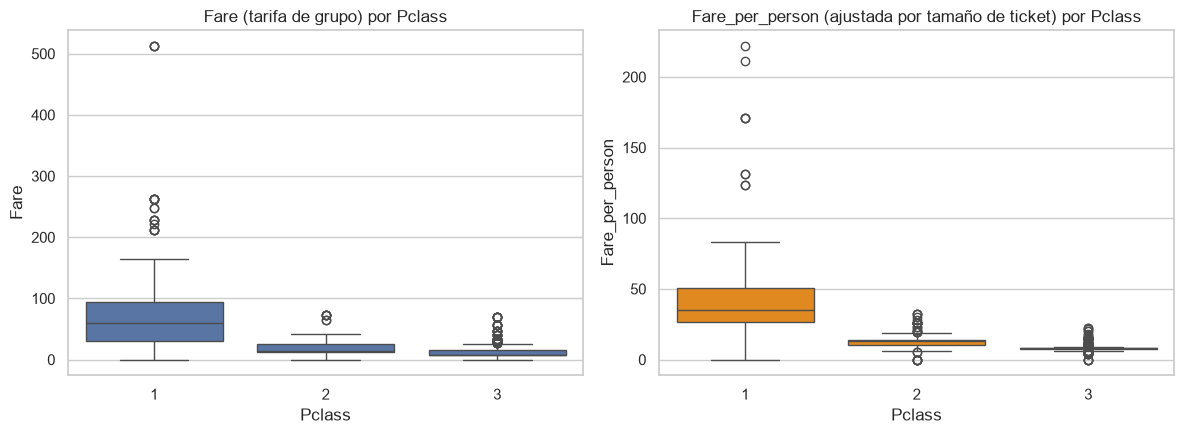

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.boxplot(data=df, x="Pclass", y="Fare", ax=axes[0])
axes[0].set_title("Fare (tarifa de grupo) por Pclass")

sns.boxplot(data=df, x="Pclass", y="Fare_per_person", ax=axes[1], color="darkorange")
axes[1].set_title("Fare_per_person (ajustada por tamaño de ticket) por Pclass")

plt.tight_layout()
plt.savefig(f"{RUTA_FIGURAS}/f4_titanic_fare_per_person.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
g0 = df.loc[df.Survived == 0, "Fare_per_person"]
g1 = df.loc[df.Survived == 1, "Fare_per_person"]
u, p_mw_fpp = stats.mannwhitneyu(g0, g1)
n0, n1 = len(g0), len(g1)
r_biserial = 1 - (2 * u) / (n0 * n1)  # signo: positivo = los sobrevivientes tienen valores mayores

print(f"Mann-Whitney U — Fare_per_person ~ Survived: U={u:.1f}  p={p_mw_fpp:.3e}  r_rango_biserial={r_biserial:.3f}  (positivo = sobrevivientes con valores mayores)")
print(f"Mediana Fare_per_person — no sobrevivió: {g0.median():.2f} | sobrevivió: {g1.median():.2f}")

g0l = df.loc[df.Survived == 0, "Fare_log"]
g1l = df.loc[df.Survived == 1, "Fare_log"]
u_log, p_mw_log = stats.mannwhitneyu(g0l, g1l)
r_biserial_log = 1 - (2 * u_log) / (len(g0l) * len(g1l))
print(f"\nReferencia (Fases 2-3), recalculada — Fare_log ~ Survived: U={u_log:.1f}  p={p_mw_log:.2e}  r_rango_biserial={r_biserial_log:.3f} (mismo orden de magnitud)")

Mann-Whitney U — Fare_per_person ~ Survived: U=58829.5  p=6.292e-21  r_rango_biserial=0.373  (positivo = sobrevivientes con valores mayores)
Mediana Fare_per_person — no sobrevivió: 8.05 | sobrevivió: 13.00

Referencia (Fases 2-3), recalculada — Fare_log ~ Survived: U=57806.5  p=4.55e-22  r_rango_biserial=0.384 (mismo orden de magnitud)


El 32.3 % de los pasajeros tiene un `TicketGroupSize` distinto de su `FamilySize`: confirma que ambas variables capturan conceptos relacionados pero no idénticos (grupo de viaje por boleto vs. núcleo familiar declarado), por lo que no es redundante mantener las dos como candidatas (se decide su destino final con evidencia, en la sección VI). `Fare_per_person` reduce apenas la asimetría de `Fare` (de 4.78 a 4.37); es la transformación `log1p` la que la corrige (0.33 para `Fare_per_person_log`, en línea con el 0.39 ya observado para `Fare_log`). Además, `Fare_per_person` mantiene una asociación con `Survived` del mismo orden que `Fare_log`, aunque ligeramente menor (r rango-biserial 0.373 frente a 0.384), por lo que no se propone por mayor relevancia marginal sino por una lectura más limpia: aísla la tarifa pagada **por persona** del efecto de "viajar en grupo grande", que ya se representa por separado con `FamilySize`/`TicketGroupSize`.

### V.2 `Sex_Pclass`: interacción explícita entre sexo y clase

**Hallazgo que la motiva:** las Fases 2-3 (apartado VIII.3, gráfico de interacción) mostraron que el efecto de `Pclass` sobre la supervivencia **no es uniforme entre sexos**: la supervivencia femenina es muy alta en 1ª y 2ª clase (96.8 % y 92.1 %) y cae con fuerza solo en 3ª (50.0 %), mientras que la masculina ya es baja en 1ª clase (36.9 %) y se hunde desde la 2ª (15.7 % y 13.5 % en 2ª y 3ª). Una variable categórica que combine ambas dimensiones puede capturar esa interacción de forma explícita, en vez de dejar que un modelo lineal la infiera solo a partir de dos variables por separado (que asumen efectos aditivos).

**Construcción:** concatenación de `Sex` y `Pclass` en una única variable categórica de 6 niveles.

In [13]:
df["Sex_Pclass"] = df["Sex"].astype(str) + "_" + df["Pclass"].astype(str)

tabla_supervivencia = df.pivot_table(index="Sex", columns="Pclass", values="Survived", aggfunc="mean").round(3)
print("Tasa de supervivencia por Sex x Pclass:")
print(tabla_supervivencia)


def cramers_v(x, y):
    # chi2_contingency aplica la corrección de continuidad de Yates solo en tablas 2x2 (igual que en las Fases 2-3)
    tabla = pd.crosstab(x, y)
    chi2, p, _, esperadas = stats.chi2_contingency(tabla)
    n = tabla.sum().sum()
    r, k = tabla.shape
    v = np.sqrt((chi2 / n) / (min(r - 1, k - 1)))
    return chi2, p, v


resultados_v = []
for nombre, serie in [("Sex", df["Sex"]), ("Pclass", df["Pclass"]), ("Sex_Pclass", df["Sex_Pclass"])]:
    chi2, p, v = cramers_v(serie, df["Survived"])
    resultados_v.append({"variable": nombre, "chi2": round(chi2, 2), "p_valor": p, "cramers_v": round(v, 3)})

tabla_v = pd.DataFrame(resultados_v)
tabla_v

Tasa de supervivencia por Sex x Pclass:
Pclass      1      2      3
Sex                        
female  0.968  0.921  0.500
male    0.369  0.157  0.135


,variable,chi2,p_valor,cramers_v
0,Sex,260.72,1.197357e-58,0.541
1,Pclass,102.89,4.549252e-23,0.340
2,Sex_Pclass,350.68,1.252307e-73,0.627


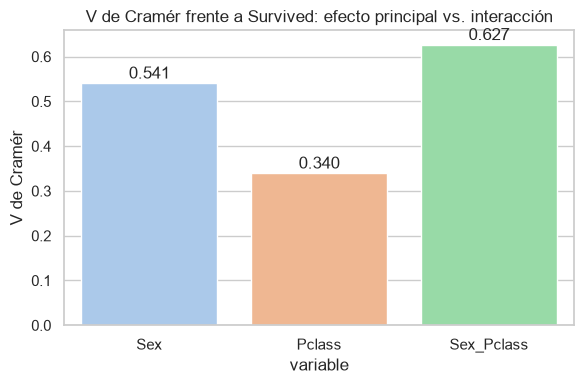

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=tabla_v, x="variable", y="cramers_v", hue="variable", palette="pastel", legend=False, ax=ax)
ax.set_title("V de Cramér frente a Survived: efecto principal vs. interacción")
ax.set_ylabel("V de Cramér")
for i, valor in enumerate(tabla_v["cramers_v"]):
    ax.text(i, valor + 0.01, f"{valor:.3f}", ha="center")
plt.tight_layout()
plt.savefig(f"{RUTA_FIGURAS}/f4_titanic_interaccion_sex_pclass.png", dpi=150, bbox_inches="tight")
plt.show()

`Sex_Pclass` tiene una V de Cramér más alta que cualquiera de sus dos variables de origen por separado. Esto es **consistente** con el hallazgo cualitativo de las Fases 2-3, pero no lo demuestra por sí solo: al cruzar dos variables categóricas, la variable resultante conoce estrictamente todo lo que cada una por separado conoce (más las distinciones cruzadas), así que su V de Cramér frente al objetivo tiende a igualar o superar a la de cada marginal **incluso si el efecto real fuera puramente aditivo**, sin ninguna interacción genuina. Para confirmar que hay una interacción real (y no solo "más información por combinar variables"), se compara formalmente un modelo aditivo (`Survived ~ Sex + Pclass`) contra el modelo saturado equivalente al cruce completo, mediante un test de razón de verosimilitudes.

*Nota sobre la V de Cramér:* en la tabla 2×2 de `Sex` frente a `Survived`, `scipy.stats.chi2_contingency` aplica la corrección de continuidad de Yates (V = 0.541; sin corrección sería 0.543); las tablas de más de dos filas no la llevan. Se mantiene la convención de las Fases 2-3 para que las cifras sean comparables.


In [15]:
def log_verosimilitud(X, y):
    modelo = LogisticRegression(penalty=None, max_iter=2000)
    modelo.fit(X, y)
    p = np.clip(modelo.predict_proba(X)[:, 1], 1e-12, 1 - 1e-12)
    n_parametros = modelo.coef_.size + 1  # + intercepto
    return np.sum(y * np.log(p) + (1 - y) * np.log(1 - p)), n_parametros


y_obj = df["Survived"].values
X_aditivo = pd.concat(
    [pd.get_dummies(df["Sex"], drop_first=True), pd.get_dummies(df["Pclass"].astype(str), drop_first=True)],
    axis=1,
).values.astype(float)
X_saturado = pd.get_dummies(df["Sex_Pclass"], drop_first=True).values.astype(float)

ll_aditivo, k_aditivo = log_verosimilitud(X_aditivo, y_obj)
ll_saturado, k_saturado = log_verosimilitud(X_saturado, y_obj)

lr_stat = 2 * (ll_saturado - ll_aditivo)
grados_libertad = k_saturado - k_aditivo
p_lr = stats.chi2.sf(lr_stat, grados_libertad)

print(f"Modelo aditivo (Sex + Pclass): log-verosimilitud={ll_aditivo:.2f}, parámetros={k_aditivo}")
print(f"Modelo saturado (Sex x Pclass completo): log-verosimilitud={ll_saturado:.2f}, parámetros={k_saturado}")
print(f"\nTest de razón de verosimilitudes (interacción vs. modelo aditivo):")
print(f"LR = {lr_stat:.2f}   df = {grados_libertad}   p = {p_lr:.2e}")

Modelo aditivo (Sex + Pclass): log-verosimilitud=-413.44, parámetros=4
Modelo saturado (Sex x Pclass completo): log-verosimilitud=-399.05, parámetros=6

Test de razón de verosimilitudes (interacción vs. modelo aditivo):
LR = 28.79   df = 2   p = 5.60e-07


El test de razón de verosimilitudes confirma que la interacción es estadísticamente significativa más allá de lo que explican los efectos aditivos de `Sex` y `Pclass` por separado (p < 0.001), lo cual sí respalda formalmente la decisión de incorporar `Sex_Pclass` como variable derivada.

### V.3 Alerta de *data leakage*

Ninguna de las dos variables derivadas usa `Survived` (ni ninguna variable posterior al hundimiento, como `alive` de la fuente `seaborn`-data, que **no** se incorpora al pipeline por esa misma razón). `Fare_per_person` se construye solo a partir de `Fare` y `Ticket`; `Sex_Pclass`, solo a partir de `Sex` y `Pclass`. Ambas están disponibles, en principio, al momento de la venta del pasaje, por lo que no hay fuga de información hacia el objetivo.

---
## VI. Selección preliminar de características

Se decide, para cada variable candidata, si se **prioriza**, **conserva**, **revisa** o **descarta**, usando cuatro criterios explícitos: (1) relevancia analítica/predictiva respecto de `Survived`, (2) redundancia con otras variables, (3) interpretabilidad, (4) consistencia/robustez de la evidencia. No se entrena ningún modelo predictivo en esta fase: la evidencia de "utilidad para modelamiento" se construye con V de Cramér, correlación de rango-biserial (ya calculadas en Fases 2-3 y en la sección V) y con información mutua (*mutual information*, en nats), una medida no paramétrica de relevancia frente al objetivo. La magnitud de la V de Cramér se lee con la convención de Cohen (1988) que usaron las Fases 2-3 (0.10 débil / 0.30 moderada / 0.50 fuerte; con `Survived` binaria los umbrales son idénticos para todas las variables), y se distingue siempre la **significancia estadística** de la **magnitud del efecto**.

### VI.1 Redundancia con las columnas heredadas de la integración `seaborn`-data

Las Fases 2-3 ya habían validado que `Pclass` ↔ `class` y `Embarked_clean` ↔ `embark_town` son exactamente la misma información con otra etiqueta (correspondencia diagonal perfecta, apartado V.2). Falta verificar lo mismo para `who`, `adult_male` y `alone`, que no se validaron explícitamente en esa fase.

In [16]:
who_reconstruido = np.where(df["Age_clean"] < 16, "child", np.where(df["Sex"] == "male", "man", "woman"))
adult_male_reconstruido = (df["Sex"] == "male") & (df["Age_clean"] >= 16)
alone_reconstruido = df["IsAlone"] == 1

coincidencia = pd.Series({
    "who == f(Sex, Age_clean<16)": (who_reconstruido == df["who"]).mean(),
    "adult_male == f(Sex, Age_clean>=16)": (adult_male_reconstruido.values == df["adult_male"].astype(bool).values).mean(),
    "alone == IsAlone": (alone_reconstruido.values == df["alone"].astype(bool).values).mean(),
}) * 100
coincidencia.round(2)

who == f(Sex, Age_clean<16)            100.0
adult_male == f(Sex, Age_clean>=16)    100.0
alone == IsAlone                       100.0
dtype: float64

Las tres coinciden en el 100 % de los 891 registros con una regla determinista a partir de columnas propias ya existentes (`Sex`, `Age_clean`, `IsAlone`). Sumado a lo ya probado en las Fases 2-3 para `class` ↔ `Pclass`, `embark_town` ↔ `Embarked_clean` y `deck` ↔ `Cabin_letra` (100 % de coincidencia en los casos con ambos datos, apartado V.2), **las seis columnas heredadas de la fuente `seaborn`-data (`class`, `who`, `adult_male`, `deck`, `embark_town`, `alone`) se descartan del set final de características**: no aportan información nueva y mantenerlas sería una forma de contar la misma señal dos veces. La información de `deck` sobrevive en `Deck_combinado`, que sí se conserva (sección VI.4).

### VI.2 Redundancia entre variables propias

Se revisan dos redundancias adicionales, no analizadas en Fases 2-3 porque en ese momento no era su objetivo: (a) `Title_agrupado` vs. `Sex_bin`, y (b) el bloque de variables numéricas relacionadas con tarifa y tamaño de grupo (`Fare_log`, `Fare_per_person_log`, `FamilySize`, `TicketGroupSize`).

In [17]:
chi2_ts, p_ts, v_ts = cramers_v(df["Title_agrupado"], df["Sex"])
print(f"Title_agrupado ~ Sex (redundancia ENTRE variables, no con el objetivo): V de Cramér = {v_ts:.3f}  (p={p_ts:.2e})")

Title_agrupado ~ Sex (redundancia ENTRE variables, no con el objetivo): V de Cramér = 0.995  (p=2.55e-188)


In [18]:
# Redundancia EXACTA vs. PARCIAL entre las variables propias candidatas
# (a) ¿Pclass es función exacta de las dummies de Sex_Pclass?  (b) ¿Cuánto del sexo explican las dummies de Title_agrupado?
dummies_sp = pd.get_dummies(df["Sex_Pclass"], drop_first=True).values.astype(float)
A = np.column_stack([np.ones(len(df)), dummies_sp])
coef, *_ = np.linalg.lstsq(A, df["Pclass"].values.astype(float), rcond=None)
residuo_pclass = np.abs(df["Pclass"].values - A @ coef).max()
print(f"Pclass ~ dummies de Sex_Pclass: residuo máximo = {residuo_pclass:.1e}  (≈ 0 => combinación lineal exacta)")

dummies_ti = pd.get_dummies(df["Title_agrupado"], drop_first=True).values.astype(float)
B = np.column_stack([np.ones(len(df)), dummies_ti])
y_mujer = (df["Sex"] == "female").astype(float).values
coef, *_ = np.linalg.lstsq(B, y_mujer, rcond=None)
r2_sexo_titulo = 1 - ((y_mujer - B @ coef) ** 2).sum() / ((y_mujer - y_mujer.mean()) ** 2).sum()
print(f"Sexo ~ dummies de Title_agrupado: R² = {r2_sexo_titulo:.3f}  (alto, pero < 1: Nobleza y Oficial_Profesional incluyen ambos sexos)")

Pclass ~ dummies de Sex_Pclass: residuo máximo = 5.7e-15  (≈ 0 => combinación lineal exacta)
Sexo ~ dummies de Title_agrupado: R² = 0.989  (alto, pero < 1: Nobleza y Oficial_Profesional incluyen ambos sexos)


In [19]:
variables_continuas = ["Age_clean", "Fare_log", "Fare_per_person_log", "FamilySize", "TicketGroupSize"]
corr_spearman = df[variables_continuas].corr(method="spearman").round(2)
corr_spearman

,Age_clean,Fare_log,Fare_per_person_log,FamilySize,TicketGroupSize
Age_clean,1.00,0.17,0.36,-0.20,-0.15
Fare_log,0.17,1.00,0.75,0.53,0.63
Fare_per_person_log,0.36,0.75,1.00,0.10,0.05
FamilySize,-0.20,0.53,0.10,1.00,0.66
TicketGroupSize,-0.15,0.63,0.05,0.66,1.00


- **`Title_agrupado` vs. `Sex`:** V de Cramér ≈ 0.995 — prácticamente redundantes entre sí. Sin embargo, `Title_agrupado` tiene mayor relevancia frente a `Survived` que `Sex` por separado (V = 0.570 vs. 0.541, Fases 2-3, apartado VIII.1), porque distingue además a los niños (`Master`) del resto de los varones adultos, algo que `Sex` no captura. **Decisión:** se conserva `Title_agrupado` como la variable categórica de sexo/estatus, y se **descarta `Sex_bin`** del set final de características por redundancia (su señal queda subsumida en `Title_agrupado`).
- **Criterio único de redundancia (exacta vs. parcial).** Se **elimina** la redundancia *exacta* (una variable es función determinista o combinación lineal exacta de otras que se conservan) y se **conserva, documentada,** la redundancia *parcial* cuando la variable aporta información propia. Exacta: `IsAlone` (función de `FamilySize`), `Sex_bin` (función de `Sex`, que no entra sola), las seis columnas de `seaborn`-data y, según la verificación anterior, **`Pclass`**, que es combinación lineal exacta de las dummies de `Sex_Pclass` (`Sex_Pclass` ya contiene `Sex` y `Pclass` completos); por eso `Pclass` se descarta aunque su V frente a `Survived` sea moderada. Parcial: `Title_agrupado` y `Sex_Pclass` (el sexo queda explicado en gran medida, no del todo, por el título; ver R² arriba): se conservan ambas porque `Title_agrupado` añade a `Master`, `Nobleza` y `Oficial_Profesional`, pero se deja registrado en las limitaciones que para un modelo lineal sin regularización esa multicolinealidad parcial exige cuidado.
- **Bloque tarifa/grupo:** `Fare_log` y `Fare_per_person_log` correlacionan fuerte entre sí (Spearman alto, ver tabla), y `Fare_log` además correlaciona de forma no trivial con `FamilySize` y `TicketGroupSize`. Esto sugiere solapamiento entre "tarifa" y "tamaño de grupo", pero una correlación entre dos predictores no dice por sí sola cuánto de la asociación de uno con `Survived` es atribuible al otro — para eso hace falta una correlación parcial, que se calcula a continuación.
- `FamilySize` y `TicketGroupSize` correlacionan moderadamente entre sí, pero la sección V.1 ya mostró que describen conceptos distintos en el 32.3 % de los casos (núcleo familiar vs. grupo de viaje/boleto) — **se conservan ambas**.

In [20]:
def residualizar(y, X):
    X = np.column_stack([np.ones(len(X)), X])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    return y - X @ beta


def spearman_parcial(x, y, controles):
    """Spearman parcial estándar: se pasan x, y y los controles a rangos, se residualiza linealmente
    sobre los rangos de los controles y se correlacionan (Pearson) los residuos."""
    rangos_controles = np.column_stack([stats.rankdata(controles[:, j]) for j in range(controles.shape[1])])
    rx = residualizar(stats.rankdata(x), rangos_controles)
    ry = residualizar(stats.rankdata(y), rangos_controles)
    return stats.pearsonr(rx, ry)[0]


controles_grupo = df[["FamilySize", "TicketGroupSize"]].values.astype(float)
surv = df["Survived"].values.astype(float)
surv_residual_lineal = residualizar(surv, controles_grupo)  # variante de sensibilidad (residuos lineales de los valores)

filas_parcial = []
for nombre in ["Fare_log", "Fare_per_person_log"]:
    x = df[nombre].values.astype(float)
    r_marginal = stats.spearmanr(x, surv)[0]
    r_parcial = spearman_parcial(x, surv, controles_grupo)
    r_lineal = stats.spearmanr(residualizar(x, controles_grupo), surv_residual_lineal)[0]
    filas_parcial.append({
        "variable": nombre, "r_marginal": round(r_marginal, 3),
        "r_parcial_rangos": round(r_parcial, 3),
        "reduccion_pct_rangos": round((1 - r_parcial / r_marginal) * 100, 1),
        "r_parcial_resid_lineales": round(r_lineal, 3),
        "reduccion_pct_resid_lineales": round((1 - r_lineal / r_marginal) * 100, 1),
    })

tabla_parcial = pd.DataFrame(filas_parcial)
tabla_parcial

,variable,r_marginal,r_parcial_rangos,reduccion_pct_rangos,r_parcial_resid_lineales,reduccion_pct_resid_lineales
0,Fare_log,0.324,0.268,17.3,0.289,10.7
1,Fare_per_person_log,0.315,0.307,2.3,0.278,11.5


La correlación parcial se calcula con la definición estándar de **Spearman parcial** (rangos → residuos → correlación de los residuos) y, como sensibilidad, con residuos lineales de los valores originales (`Survived` es binaria, por lo que esa variante es menos apropiada). **El resultado depende del método y conviene decirlo:**

- **Spearman parcial (método base):** controlar por `FamilySize` y `TicketGroupSize` reduce la asociación de `Fare_log` con `Survived` en 17.3 % (0.324 → 0.268), pero la de `Fare_per_person_log` solo en 2.3 % (0.315 → 0.307). La variable por persona depende mucho menos del tamaño del grupo, que es justamente lo que su construcción busca.
- **Residuos lineales (sensibilidad):** ambas caen de forma parecida (10.7 % y 11.5 %), sin distinguirse.

Lo que **no** respalda la evidencia es que `Fare_per_person_log` sea *más relevante* que `Fare_log`: su asociación marginal es ligeramente menor (Spearman 0.315 frente a 0.324; rango-biserial 0.373 frente a 0.384) y también lo es su información mutua media (≈ 0.11 frente a ≈ 0.13 con 21 semillas, sección VI.3). Se **prioriza `Fare_per_person_log` sobre `Fare_log`** por interpretabilidad y por menor confusión con el tamaño del grupo (`FamilySize`/`TicketGroupSize`), no por mayor poder asociativo. Por la misma razón (redundancia con `Fare_per_person_log` y con el tamaño del grupo), se **descartan `Fare_log` y `FareBand`** (su versión discretizada) del set final, dejando `FamilySize` y `TicketGroupSize` como las variables encargadas de representar el tamaño del grupo.

### VI.3 Relevancia: información mutua frente a `Survived`

Como evidencia adicional de "utilidad para una etapa posterior de modelamiento" (sin entrenar un modelo), se calcula la información mutua (en nats) de cada variable candidata (ya sobreviviente de los descartes anteriores, más algunos casos límite) respecto de `Survived`. `FamilySize` y `TicketGroupSize` son conteos enteros y se tratan como **discretas**.

In [21]:
candidatas_mi = {
    "Pclass": "cat", "Title_agrupado": "cat", "Sex_Pclass": "cat", "AgeGroup": "cat",
    "Age_clean": "num", "Fare_per_person_log": "num", "FamilySize": "disc",
    "TicketGroupSize": "disc", "IsAlone": "cat", "Embarked_clean": "cat", "Deck_combinado": "cat",
}

X_mi = pd.DataFrame(index=df.index)
es_discreta = []
for columna, tipo in candidatas_mi.items():
    if tipo == "cat":
        X_mi[columna] = LabelEncoder().fit_transform(df[columna].astype(str))
        es_discreta.append(True)
    elif tipo == "disc":
        X_mi[columna] = df[columna]  # conteo entero: discreta
        es_discreta.append(True)
    else:
        X_mi[columna] = df[columna]  # continua
        es_discreta.append(False)

mi = mutual_info_classif(X_mi, df["Survived"], discrete_features=es_discreta, random_state=RANDOM_STATE)
ranking_mi = pd.Series(mi, index=X_mi.columns, name="informacion_mutua_nats").sort_values(ascending=False).round(3)
ranking_mi

Sex_Pclass             0.218
Title_agrupado         0.169
Fare_per_person_log    0.110
Age_clean              0.068
Pclass                 0.058
TicketGroupSize        0.058
Deck_combinado         0.055
FamilySize             0.048
IsAlone                0.021
Embarked_clean         0.014
AgeGroup               0.009
Name: informacion_mutua_nats, dtype: float64

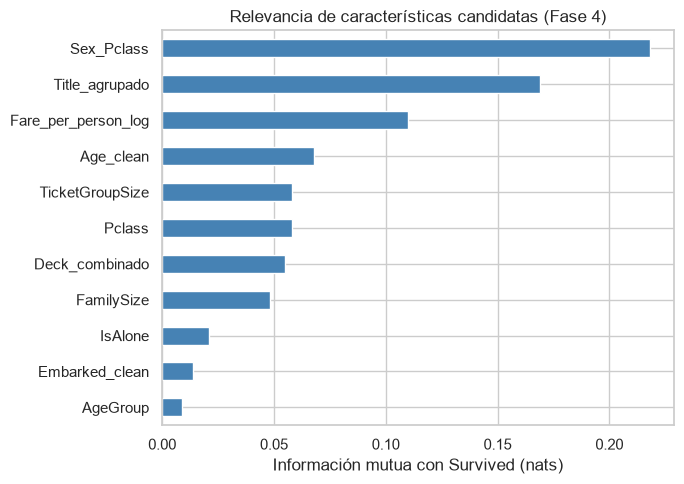

In [22]:
fig, ax = plt.subplots(figsize=(7, 5))
ranking_mi.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Información mutua con Survived (nats)")
ax.set_title("Relevancia de características candidatas (Fase 4)")
plt.tight_layout()
plt.savefig(f"{RUTA_FIGURAS}/f4_titanic_mutual_information.png", dpi=150, bbox_inches="tight")
plt.show()

Antes de leer el ranking como si fuera un número exacto, conviene tener presentes cuatro cautelas metodológicas:

1. **Unidades:** `mutual_info_classif` entrega nats (el máximo posible es la entropía de `Survived`, ≈ 0.665 nats).
2. **Dos estimadores distintos:** para variables discretas es un estimador directo (determinista); para las continuas (`Age_clean`, `Fare_per_person_log`) usa un método de vecinos más cercanos (Kraskov et al., 2004) que agrega ruido aleatorio. Ambos no son estrictamente comparables, y el estimador discreto tiende a sobreestimar con muchas categorías (`Deck_combinado`, 9 niveles; `Title_agrupado`, 6). Por eso el ranking se lee como **orden aproximado**, no como valores exactos.
3. **Conteos enteros:** `FamilySize` y `TicketGroupSize` se tratan como discretas. Tratarlas como continuas induce una inestabilidad artificial: `FamilySize` oscila entre 0.019 y 0.085 según la semilla y llega a quedar por debajo de `IsAlone`, que es función suya, lo cual es imposible para la información mutua verdadera.
4. **Estabilidad frente a la semilla:** se repite el cálculo con 21 semillas.

In [23]:
comparacion_semillas = pd.DataFrame({
    f"seed_{s}": mutual_info_classif(X_mi, df["Survived"], discrete_features=es_discreta, random_state=s)
    for s in SEMILLAS_MI
}, index=X_mi.columns)

resumen_semillas = pd.DataFrame({
    f"seed_{RANDOM_STATE}": comparacion_semillas[f"seed_{RANDOM_STATE}"],
    "media": comparacion_semillas.mean(axis=1),
    "min": comparacion_semillas.min(axis=1),
    "max": comparacion_semillas.max(axis=1),
}).round(3)
resumen_semillas["rango_max_min"] = (resumen_semillas["max"] - resumen_semillas["min"]).round(3)

top3_ref = set(ranking_mi.index[:3])
bottom2_ref = set(ranking_mi.index[-2:])
top3_estable = all(set(comparacion_semillas[c].nlargest(3).index) == top3_ref for c in comparacion_semillas)
bottom2_estable = all(set(comparacion_semillas[c].nsmallest(2).index) == bottom2_ref for c in comparacion_semillas)
print(f"Semillas evaluadas: {len(SEMILLAS_MI)}")
print(f"Tres primeras {sorted(top3_ref)} idénticas en todas las semillas: {top3_estable}")
print(f"Dos últimas {sorted(bottom2_ref)} idénticas en todas las semillas: {bottom2_estable}")
# Comparación de las dos variables de tarifa (ambas continuas, mismo estimador), 21 semillas
mi_tarifa = pd.DataFrame({
    col: [mutual_info_classif(df[[col]], df["Survived"], discrete_features=False, random_state=s)[0] for s in SEMILLAS_MI]
    for col in ["Fare_log", "Fare_per_person_log"]
})
print("Información mutua media (21 semillas): " + " | ".join(f"{c}: {mi_tarifa[c].mean():.3f}" for c in mi_tarifa))
resumen_semillas.sort_values(f"seed_{RANDOM_STATE}", ascending=False)

Semillas evaluadas: 21
Tres primeras ['Fare_per_person_log', 'Sex_Pclass', 'Title_agrupado'] idénticas en todas las semillas: True
Dos últimas ['AgeGroup', 'Embarked_clean'] idénticas en todas las semillas: True
Información mutua media (21 semillas): Fare_log: 0.132 | Fare_per_person_log: 0.109


,seed_42,media,min,max,rango_max_min
Sex_Pclass,0.218,0.218,0.218,0.218,0.000
Title_agrupado,0.169,0.169,0.169,0.169,0.000
Fare_per_person_log,0.110,0.106,0.092,0.122,0.030
Age_clean,0.068,0.046,0.016,0.070,0.054
Pclass,0.058,0.058,0.058,0.058,0.000
TicketGroupSize,0.058,0.058,0.058,0.058,0.000
Deck_combinado,0.055,0.055,0.055,0.055,0.000
FamilySize,0.048,0.048,0.048,0.048,0.000
IsAlone,0.021,0.021,0.021,0.021,0.000
Embarked_clean,0.014,0.014,0.014,0.014,0.000


Tres observaciones, ya con esta verificación de estabilidad (21 semillas):

1. **El extremo superior es estable:** `Sex_Pclass`, `Title_agrupado` y `Fare_per_person_log` quedan siempre en los tres primeros lugares, sin importar la semilla. Su información mutua es además, por construcción, la más alta (`Sex_Pclass` y `Title_agrupado` incluyen el sexo).
2. **El extremo inferior también es estable:** `AgeGroup` y `Embarked_clean` quedan siempre entre las de menor información mutua. Para `AgeGroup` esto contrasta con que su V de Cramér frente a `Survived` es estadísticamente significativa (V = 0.137, p = 0.002): significancia estadística y magnitud del efecto no son lo mismo, y con 891 casos incluso una asociación débil puede resultar significativa. Se mantiene `AgeGroup` en estado **"Revisar"** (no se descarta) porque codifica el patrón "niños primero", de sentido sustantivo bien documentado para este dataset; se documenta explícitamente que su aporte cuantitativo es marginal.
3. **Solo las variables continuas son inestables** (`Fare_per_person_log` y `Age_clean`, con el estimador de vecinos); las discretas (`Pclass`, `Deck_combinado`, `TicketGroupSize`, `FamilySize`, `IsAlone`, `Embarked_clean`, `AgeGroup`) tienen valores exactamente reproducibles. Ahora `FamilySize` (0.048) supera a `IsAlone` (0.021), como debe ocurrir por la desigualdad de procesamiento de datos, ya que `IsAlone` es función determinista de `FamilySize`. Se **descarta `IsAlone`** por esa redundancia exacta (y su menor información mutua es consistente con ello).

**Sobre `Age_clean`.** Se descarta como variable numérica independiente, pero la justificación debe ser precisa: (a) la prueba de Mann-Whitney no encuentra diferencia entre grupos (ver tabla de evidencia de la sección VI.3b), pero esa prueba solo detecta desplazamientos monótonos y el efecto de la edad es no monótono (niños con mayor supervivencia, mayores con menor); (b) la **información mutua de `Age_clean` supera siempre a la de `AgeGroup`** (ver tabla), es decir, la discretización en cinco grupos pierde información; (c) aun así, el 19.9 % de las edades (177 casos) está **imputado** con medianas de `Pclass × Sex`, por lo que parte de la información continua es sintética, y `AgeGroup` la agrega en tramos interpretables. Se descarta por esa combinación de imputación e interpretabilidad, y se deja anotado como punto a **revalidar con el desempeño de un modelo** (`Age_clean` escalada es la alternativa natural).

### VI.3b Evidencia de asociación de las candidatas (recalculada)

Las cifras de los apartados anteriores que provienen de las Fases 2-3 se **recalculan aquí sobre el dataset preparado reconstruido en II.2** (en lugar de citarlas), junto con la evidencia sobre las columnas que aún no tenían decisión (`Age_registrada`, `Cabin_registrada`). La lectura de la magnitud de V usa la convención de Cohen (1988): 0.10 / 0.30 / 0.50.

In [24]:
def lectura_v(v):
    return "fuerte" if v >= 0.50 else "moderada" if v >= 0.30 else "débil" if v >= 0.10 else "muy débil"


def pct_esperadas_bajas(x, y):
    esperadas = stats.chi2_contingency(pd.crosstab(x, y))[3]
    return (esperadas < 5).mean() * 100


V, P_CAT, PCT_BAJAS = {}, {}, {}
filas = []
for columna in ["Sex", "Pclass", "Sex_Pclass", "Title_agrupado", "Deck_combinado", "Embarked_clean", "AgeGroup",
                "Cabin_registrada", "Age_registrada"]:
    chi2, p, v = cramers_v(df[columna], df["Survived"])
    V[columna], P_CAT[columna], PCT_BAJAS[columna] = v, p, pct_esperadas_bajas(df[columna], df["Survived"])
    filas.append({"variable": columna, "chi2": round(chi2, 2), "p_valor": p, "V_Cramer": round(v, 3),
                  "magnitud": lectura_v(v), "%_celdas_esperadas<5": round(PCT_BAJAS[columna], 1)})
evidencia_cat = pd.DataFrame(filas)


def mw_rango_biserial(serie):
    g0, g1 = serie[df["Survived"] == 0].dropna(), serie[df["Survived"] == 1].dropna()
    u, p = stats.mannwhitneyu(g0, g1)
    return {"n": len(g0) + len(g1), "p_valor": p, "r_rango_biserial": round(1 - 2 * u / (len(g0) * len(g1)), 3)}


evidencia_num = pd.DataFrame({
    "Age_clean (con 177 imputadas)": mw_rango_biserial(df["Age_clean"]),
    "Age (solo observadas)": mw_rango_biserial(df["Age"]),
    "FamilySize": mw_rango_biserial(df["FamilySize"]),
    "TicketGroupSize": mw_rango_biserial(df["TicketGroupSize"]),
}).T

deck_conocido = (df["Deck_combinado"] != "Desconocida").astype(int)
coincide_cabin = (df["Cabin_registrada"] == deck_conocido).mean() * 100
v_emb_pclass = cramers_v(df["Embarked_clean"], df["Pclass"])[2]
tasas_cabin = df.groupby("Cabin_registrada")["Survived"].mean().round(3).to_dict()
tasas_age = df.groupby("Age_registrada")["Survived"].mean().round(3).to_dict()

print("V de Cramér frente a Survived (magnitud según Cohen, 1988):")
display(evidencia_cat)
print("\nMann-Whitney frente a Survived:")
display(evidencia_num)
print(f"\nCabin_registrada coincide con (Deck_combinado != 'Desconocida') en {coincide_cabin:.1f} % de los registros")
print(f"Supervivencia según Cabin_registrada (0=no, 1=sí): {tasas_cabin}")
print(f"Supervivencia según Age_registrada  (0=imputada, 1=observada): {tasas_age}")
print(f"V de Cramér Embarked_clean ~ Pclass = {v_emb_pclass:.3f} (parte del efecto del puerto refleja la clase)")

V de Cramér frente a Survived (magnitud según Cohen, 1988):


,variable,chi2,p_valor,V_Cramer,magnitud,%_celdas_esperadas<5
0,Sex,260.72,1.197357e-58,0.541,fuerte,0.0
1,Pclass,102.89,4.549252e-23,0.340,moderada,0.0
2,Sex_Pclass,350.68,1.252307e-73,0.627,fuerte,0.0
3,Title_agrupado,289.84,1.532591e-60,0.570,fuerte,16.7
4,Deck_combinado,99.16,6.326020e-18,0.334,moderada,27.8
5,Embarked_clean,25.96,2.300863e-06,0.171,débil,0.0
6,AgeGroup,16.69,2.217583e-03,0.137,débil,0.0
7,Cabin_registrada,87.94,6.741970e-21,0.314,moderada,0.0
8,Age_registrada,7.11,7.682742e-03,0.089,muy débil,0.0



Mann-Whitney frente a Survived:


,n,p_valor,r_rango_biserial
Age_clean (con 177 imputadas),891.0,2.499530e-01,-0.046
Age (solo observadas),714.0,1.604925e-01,-0.062
FamilySize,891.0,7.970801e-07,0.173
TicketGroupSize,891.0,6.187997e-08,0.188



Cabin_registrada coincide con (Deck_combinado != 'Desconocida') en 100.0 % de los registros
Supervivencia según Cabin_registrada (0=no, 1=sí): {0: 0.3, 1: 0.667}
Supervivencia según Age_registrada  (0=imputada, 1=observada): {0: 0.294, 1: 0.406}
V de Cramér Embarked_clean ~ Pclass = 0.262 (parte del efecto del puerto refleja la clase)


### VI.4 Tabla de decisiones final

In [25]:
decisiones = pd.DataFrame([
    {"variable": "Sex_Pclass", "decision": "Priorizar",
     "criterio_principal": f"Relevancia: V={V['Sex_Pclass']:.3f} ({lectura_v(V['Sex_Pclass'])}) e información mutua más alta; interacción confirmada (LR p={p_lr:.1e})"},
    {"variable": "Title_agrupado", "decision": "Priorizar",
     "criterio_principal": f"Relevancia: V={V['Title_agrupado']:.3f} ({lectura_v(V['Title_agrupado'])}); distingue a los niños (Master); redundancia solo parcial con Sex_Pclass"},
    {"variable": "Fare_per_person_log", "decision": "Conservar",
     "criterio_principal": f"Asociación moderada (r rango-biserial={r_biserial:.3f}); menos dependiente del tamaño del grupo que Fare_log (Spearman parcial cae {tabla_parcial.loc[1, 'reduccion_pct_rangos']} % frente a {tabla_parcial.loc[0, 'reduccion_pct_rangos']} %); reemplaza a Fare_log por interpretabilidad, no por mayor relevancia"},
    {"variable": "FamilySize", "decision": "Conservar",
     "criterio_principal": f"Asociación débil pero significativa (r rango-biserial={evidencia_num.loc['FamilySize', 'r_rango_biserial']}, p={evidencia_num.loc['FamilySize', 'p_valor']:.2e}); concepto distinto de TicketGroupSize"},
    {"variable": "TicketGroupSize", "decision": "Conservar",
     "criterio_principal": f"Insumo de Fare_per_person y señal propia (r rango-biserial={evidencia_num.loc['TicketGroupSize', 'r_rango_biserial']}, p={evidencia_num.loc['TicketGroupSize', 'p_valor']:.2e}); difiere de FamilySize en {pct_distinto:.0f} % de los casos"},
    {"variable": "AgeGroup", "decision": "Revisar",
     "criterio_principal": f"Asociación {lectura_v(V['AgeGroup'])} (V={V['AgeGroup']:.3f}, p={P_CAT['AgeGroup']:.3f}) e información mutua marginal; se mantiene por su sentido sustantivo ('niños primero')"},
    {"variable": "Embarked_clean", "decision": "Revisar",
     "criterio_principal": f"Asociación {lectura_v(V['Embarked_clean'])} (V={V['Embarked_clean']:.3f}) e información mutua marginal; parte del efecto refleja la clase (V con Pclass={v_emb_pclass:.3f}); mismo trato que AgeGroup por evidencia equivalente"},
    {"variable": "Deck_combinado", "decision": "Revisar",
     "criterio_principal": f"Asociación {lectura_v(V['Deck_combinado'])} (V={V['Deck_combinado']:.3f}) pero {PCT_BAJAS['Deck_combinado']:.1f} % de celdas esperadas < 5 (> 20 %, regla de Cochran: interpretar con cautela) y {(df['Deck_combinado'] == 'Desconocida').mean() * 100:.1f} % de registros en la categoría explícita 'Desconocida' (no imputada)"},
    {"variable": "Pclass", "decision": "Descartar",
     "criterio_principal": f"Redundancia exacta: combinación lineal de las dummies de Sex_Pclass (residuo={residuo_pclass:.0e}); su asociación (V={V['Pclass']:.3f}, {lectura_v(V['Pclass'])}) queda dentro de Sex_Pclass"},
    {"variable": "Age_clean", "decision": "Descartar",
     "criterio_principal": f"Mann-Whitney sin diferencia (p={evidencia_num.loc['Age_clean (con 177 imputadas)', 'p_valor']:.2f}; p={evidencia_num.loc['Age (solo observadas)', 'p_valor']:.2f} con edades observadas), pero la prueba no detecta efectos no monótonos y la información mutua sí es mayor que la de AgeGroup; 19.9 % imputado; se prioriza AgeGroup por interpretabilidad (revalidar con un modelo)"},
    {"variable": "Sex_bin", "decision": "Descartar",
     "criterio_principal": "Redundante con Title_agrupado (V=0.995) y con Sex_Pclass, que tienen mayor relevancia"},
    {"variable": "Fare_log", "decision": "Descartar",
     "criterio_principal": "Redundante con Fare_per_person_log y con el tamaño del grupo (su asociación marginal es algo mayor, pero depende más del tamaño del grupo)"},
    {"variable": "FareBand", "decision": "Descartar",
     "criterio_principal": "Versión discretizada de Fare, superada por Fare_per_person_log"},
    {"variable": "IsAlone", "decision": "Descartar",
     "criterio_principal": "Redundancia exacta: función determinista de FamilySize (y menor información mutua)"},
    {"variable": "Age_registrada", "decision": "Descartar",
     "criterio_principal": f"Indicador de imputación de Age; asociación {lectura_v(V['Age_registrada'])} (V={V['Age_registrada']:.3f}); la edad imputada ya está resumida en AgeGroup"},
    {"variable": "Cabin_registrada", "decision": "Descartar",
     "criterio_principal": f"Redundancia exacta: coincide {coincide_cabin:.0f} % con 'Deck_combinado distinto de Desconocida' (esa señal sobrevive en las dummies de cubierta)"},
    {"variable": "class/who/adult_male/deck/embark_town/alone", "decision": "Descartar",
     "criterio_principal": "100 % redundantes con columnas propias (Pclass, Sex, Age_clean, Cabin_letra, Embarked_clean, IsAlone)"},
])
with pd.option_context("display.max_colwidth", None):
    display(decisiones)

,variable,decision,criterio_principal
0,Sex_Pclass,Priorizar,Relevancia: V=0.627 (fuerte) e información mutua más alta; interacción confirmada (LR p=5.6e-07)
1,Title_agrupado,Priorizar,Relevancia: V=0.570 (fuerte); distingue a los niños (Master); redundancia solo parcial con Sex_Pclass
2,Fare_per_person_log,Conservar,"Asociación moderada (r rango-biserial=0.373); menos dependiente del tamaño del grupo que Fare_log (Spearman parcial cae 2.3 % frente a 17.3 %); reemplaza a Fare_log por interpretabilidad, no por mayor relevancia"
3,FamilySize,Conservar,"Asociación débil pero significativa (r rango-biserial=0.173, p=7.97e-07); concepto distinto de TicketGroupSize"
4,TicketGroupSize,Conservar,"Insumo de Fare_per_person y señal propia (r rango-biserial=0.188, p=6.19e-08); difiere de FamilySize en 32 % de los casos"
5,AgeGroup,Revisar,"Asociación débil (V=0.137, p=0.002) e información mutua marginal; se mantiene por su sentido sustantivo ('niños primero')"
6,Embarked_clean,Revisar,Asociación débil (V=0.171) e información mutua marginal; parte del efecto refleja la clase (V con Pclass=0.262); mismo trato que AgeGroup por evidencia equivalente
7,Deck_combinado,Revisar,"Asociación moderada (V=0.334) pero 27.8 % de celdas esperadas < 5 (> 20 %, regla de Cochran: interpretar con cautela) y 77.1 % de registros en la categoría explícita 'Desconocida' (no imputada)"
8,Pclass,Descartar,"Redundancia exacta: combinación lineal de las dummies de Sex_Pclass (residuo=6e-15); su asociación (V=0.340, moderada) queda dentro de Sex_Pclass"
9,Age_clean,Descartar,"Mann-Whitney sin diferencia (p=0.25; p=0.16 con edades observadas), pero la prueba no detecta efectos no monótonos y la información mutua sí es mayor que la de AgeGroup; 19.9 % imputado; se prioriza AgeGroup por interpretabilidad (revalidar con un modelo)"


### VI.5 Inventario completo de columnas (trazabilidad 32 → 36 → 29)

La tabla anterior agrupa las decisiones sobre las variables candidatas. Para que **ninguna columna quede sin destino documentado**, el inventario siguiente recorre las 36 columnas disponibles en este punto (las 32 del dataset preparado de las Fases 2-3 más las 4 creadas en esta fase) y verifica con una aserción que no falta ninguna.

In [26]:
INV = "Insumo (no entra sola)"
SET = "Set final (característica)"
DES = "Descartada"
inventario = pd.DataFrame([
    ("PassengerId", "Fases 2-3", "Set final (identificador)", "Solo trazabilidad; excluir de X al modelar"),
    ("Survived", "Fases 2-3", "Set final (objetivo)", "Variable objetivo"),
    ("Pclass", "Fases 2-3", DES, "Combinación lineal exacta de Sex_Pclass (redundancia exacta)"),
    ("Name", "Fases 2-3", DES, "Texto libre; su información útil ya se extrajo en Title_agrupado"),
    ("Sex", "Fases 2-3", INV, "Insumo de Sex_Pclass"),
    ("Age", "Fases 2-3", DES, "Versión con 177 faltantes; reemplazada por Age_clean/AgeGroup"),
    ("SibSp", "Fases 2-3", INV, "Insumo de FamilySize (Fases 2-3)"),
    ("Parch", "Fases 2-3", INV, "Insumo de FamilySize (Fases 2-3)"),
    ("Ticket", "Fases 2-3", INV, "Insumo de TicketGroupSize"),
    ("Fare", "Fases 2-3", INV, "Insumo de Fare_per_person"),
    ("Cabin", "Fases 2-3", DES, "77.1 % de faltantes; resumida en Deck_combinado"),
    ("Embarked", "Fases 2-3", DES, "Reemplazada por Embarked_clean (sin faltantes)"),
    ("Embarked_clean", "Fases 2-3", SET, "Revisar (efecto débil)"),
    ("Age_registrada", "Fases 2-3", DES, "Indicador de imputación; efecto muy débil"),
    ("Age_clean", "Fases 2-3", DES, "Ver VI.3 (imputada en 19.9 %; se prioriza AgeGroup)"),
    ("Cabin_registrada", "Fases 2-3", DES, "Redundante con las dummies de Deck_combinado"),
    ("Cabin_letra", "Fases 2-3", INV, "Insumo de Deck_combinado"),
    ("class", "Fases 2-3", DES, "Idéntica a Pclass (seaborn-data)"),
    ("who", "Fases 2-3", DES, "Función de Sex y Age_clean (seaborn-data)"),
    ("adult_male", "Fases 2-3", DES, "Función de Sex y Age_clean (seaborn-data)"),
    ("deck", "Fases 2-3", DES, "Subconjunto de Cabin_letra (seaborn-data)"),
    ("embark_town", "Fases 2-3", DES, "Idéntica a Embarked_clean (seaborn-data)"),
    ("alone", "Fases 2-3", DES, "Idéntica a IsAlone (seaborn-data)"),
    ("Sex_bin", "Fases 2-3", DES, "Redundante con Title_agrupado y Sex_Pclass"),
    ("Title", "Fases 2-3", INV, "Insumo de Title_agrupado (versión sin agrupar)"),
    ("Title_agrupado", "Fases 2-3", SET, "Priorizar"),
    ("FamilySize", "Fases 2-3", SET, "Conservar"),
    ("IsAlone", "Fases 2-3", DES, "Función determinista de FamilySize"),
    ("AgeGroup", "Fases 2-3", SET, "Revisar (efecto débil, sentido sustantivo)"),
    ("Fare_log", "Fases 2-3", DES, "Reemplazada por Fare_per_person_log"),
    ("FareBand", "Fases 2-3", DES, "Discretización de Fare, superada"),
    ("Deck_combinado", "Fases 2-3", SET, "Revisar (77.1 % 'Desconocida')"),
    ("TicketGroupSize", "Fase 4", SET, "Conservar (creada en V.1)"),
    ("Fare_per_person", "Fase 4", INV, "Insumo de Fare_per_person_log (solo se usa su log)"),
    ("Fare_per_person_log", "Fase 4", SET, "Conservar (creada en V.1)"),
    ("Sex_Pclass", "Fase 4", SET, "Priorizar (creada en V.2)"),
], columns=["columna", "origen", "destino", "motivo"])

assert set(inventario["columna"]) == set(df.columns) and inventario["columna"].is_unique, "Hay columnas sin destino documentado"
print("Columnas inventariadas:", len(inventario), "(32 del dataset preparado de las Fases 2-3 + 4 creadas en esta fase)")
print(inventario["destino"].value_counts().to_string())
with pd.option_context("display.max_colwidth", None, "display.max_rows", 60):
    display(inventario)

Columnas inventariadas: 36 (32 del dataset preparado de las Fases 2-3 + 4 creadas en esta fase)
destino
Descartada                    18
Insumo (no entra sola)         8
Set final (característica)     8
Set final (identificador)      1
Set final (objetivo)           1


,columna,origen,destino,motivo
0,PassengerId,Fases 2-3,Set final (identificador),Solo trazabilidad; excluir de X al modelar
1,Survived,Fases 2-3,Set final (objetivo),Variable objetivo
2,Pclass,Fases 2-3,Descartada,Combinación lineal exacta de Sex_Pclass (redundancia exacta)
3,Name,Fases 2-3,Descartada,Texto libre; su información útil ya se extrajo en Title_agrupado
4,Sex,Fases 2-3,Insumo (no entra sola),Insumo de Sex_Pclass
5,Age,Fases 2-3,Descartada,Versión con 177 faltantes; reemplazada por Age_clean/AgeGroup
6,SibSp,Fases 2-3,Insumo (no entra sola),Insumo de FamilySize (Fases 2-3)
7,Parch,Fases 2-3,Insumo (no entra sola),Insumo de FamilySize (Fases 2-3)
8,Ticket,Fases 2-3,Insumo (no entra sola),Insumo de TicketGroupSize
9,Fare,Fases 2-3,Insumo (no entra sola),Insumo de Fare_per_person


---
## VII. Documentación y trazabilidad del pipeline

Bitácora consolidada de las acciones aplicadas en este notebook, en orden de ejecución, con su efecto verificable en los datos. Cada fila corresponde a una celda de código ya ejecutada arriba; se reconstruye aquí como tabla única para facilitar la trazabilidad de las decisiones y de sus efectos en los datos.

In [27]:
bitacora = pd.DataFrame([
    {"paso": 1, "seccion": "IV", "accion": "Diagnóstico de asimetría residual",
     "variables": "Age_clean, Fare_log, SibSp, Parch, FamilySize",
     "efecto_o_justificacion": f"Asimetrías: SibSp {asimetrias['SibSp']}, Parch {asimetrias['Parch']}, FamilySize {asimetrias['FamilySize']}, Age_clean {asimetrias['Age_clean']}, Fare_log {asimetrias['Fare_log']}; solo Fare ya fue tratada, SibSp/Parch ya están resueltas vía FamilySize"},
    {"paso": 2, "seccion": "V.1", "accion": "Creación de TicketGroupSize y Fare_per_person(_log)",
     "variables": "Ticket, Fare -> TicketGroupSize, Fare_per_person, Fare_per_person_log",
     "efecto_o_justificacion": f"Asimetría de Fare {stats.skew(df['Fare']):.2f} -> {stats.skew(df['Fare_per_person']):.2f} (Fare_per_person) -> {stats.skew(df['Fare_per_person_log']):.2f} (log1p); r rango-biserial={r_biserial:.3f} vs. Survived (p={p_mw_fpp:.1e})"},
    {"paso": 3, "seccion": "V.2", "accion": "Creación de interacción Sex_Pclass y test de razón de verosimilitudes",
     "variables": "Sex, Pclass -> Sex_Pclass",
     "efecto_o_justificacion": f"V de Cramér sube de {tabla_v.loc[0, 'cramers_v']:.3f}/{tabla_v.loc[1, 'cramers_v']:.3f} (efectos simples) a {tabla_v.loc[2, 'cramers_v']:.3f} (cruce); interacción confirmada: LR={lr_stat:.2f}, gl={grados_libertad}, p={p_lr:.1e}"},
    {"paso": 4, "seccion": "VI.1", "accion": "Verificación de redundancia con columnas seaborn-data",
     "variables": "who, adult_male, alone, class, embark_town, deck",
     "efecto_o_justificacion": "Coincidencia del 100 % con reglas sobre columnas propias -> se descartan del set final"},
    {"paso": 5, "seccion": "VI.2", "accion": "Redundancia exacta vs. parcial entre variables propias; Spearman parcial del bloque tarifa/grupo",
     "variables": "Pclass, Sex_Pclass, Title_agrupado, Sex_bin; Fare_log vs Fare_per_person_log",
     "efecto_o_justificacion": f"Pclass es combinación lineal exacta de Sex_Pclass (residuo {residuo_pclass:.0e}) -> se descarta; Title~Sex V=0.995 y R²={r2_sexo_titulo:.3f} (parcial) -> se conserva Title_agrupado y se descarta Sex_bin; Spearman parcial: Fare_log cae {tabla_parcial.loc[0, 'reduccion_pct_rangos']} % y Fare_per_person_log {tabla_parcial.loc[1, 'reduccion_pct_rangos']} %"},
    {"paso": 6, "seccion": "VI.3", "accion": "Información mutua (nats) con verificación de estabilidad en 21 semillas",
     "variables": "11 variables candidatas vs Survived",
     "efecto_o_justificacion": f"Extremos estables (superior: {', '.join(sorted(top3_ref))}; inferior: {', '.join(sorted(bottom2_ref))}); solo las continuas varían con la semilla; FamilySize y TicketGroupSize tratadas como discretas"},
    {"paso": 7, "seccion": "VI.3b-VI.4", "accion": "Recálculo de la evidencia (V de Cramér, Mann-Whitney) y tabla de decisiones",
     "variables": "Todas las candidatas y los indicadores Age_registrada/Cabin_registrada",
     "efecto_o_justificacion": "Clasificación explícita: priorizar / conservar / revisar / descartar, con cifras calculadas en el propio notebook"},
    {"paso": 8, "seccion": "VI.5", "accion": "Inventario de las 36 columnas disponibles",
     "variables": "Todas",
     "efecto_o_justificacion": f"Cada columna tiene destino documentado (verificado con aserción): {inventario['destino'].value_counts().to_dict()}"},
    {"paso": 9, "seccion": "VIII", "accion": "Codificación one-hot con categoría de referencia explícita y escalado robusto",
     "variables": "Ver sección VIII",
     "efecto_o_justificacion": "24 indicadoras + 3 escaladas (_rs) + PassengerId y Survived = 29 columnas; rango completo de la matriz y ausencia de faltantes verificados con aserciones"},
    {"paso": 10, "seccion": "VIII", "accion": "Diagnóstico del escalado y exportación",
     "variables": "Fare_per_person_log, FamilySize, TicketGroupSize",
     "efecto_o_justificacion": "Mediana=0 e IQR=1; los extremos se conservan; exportación a titanic_features.csv"},
])
with pd.option_context("display.max_colwidth", None):
    display(bitacora)

,paso,seccion,accion,variables,efecto_o_justificacion
0,1,IV,Diagnóstico de asimetría residual,"Age_clean, Fare_log, SibSp, Parch, FamilySize","Asimetrías: SibSp 3.689, Parch 2.744, FamilySize 2.723, Age_clean 0.533, Fare_log 0.394; solo Fare ya fue tratada, SibSp/Parch ya están resueltas vía FamilySize"
1,2,V.1,Creación de TicketGroupSize y Fare_per_person(_log),"Ticket, Fare -> TicketGroupSize, Fare_per_person, Fare_per_person_log",Asimetría de Fare 4.78 -> 4.37 (Fare_per_person) -> 0.33 (log1p); r rango-biserial=0.373 vs. Survived (p=6.3e-21)
2,3,V.2,Creación de interacción Sex_Pclass y test de razón de verosimilitudes,"Sex, Pclass -> Sex_Pclass","V de Cramér sube de 0.541/0.340 (efectos simples) a 0.627 (cruce); interacción confirmada: LR=28.79, gl=2, p=5.6e-07"
3,4,VI.1,Verificación de redundancia con columnas seaborn-data,"who, adult_male, alone, class, embark_town, deck",Coincidencia del 100 % con reglas sobre columnas propias -> se descartan del set final
4,5,VI.2,Redundancia exacta vs. parcial entre variables propias; Spearman parcial del bloque tarifa/grupo,"Pclass, Sex_Pclass, Title_agrupado, Sex_bin; Fare_log vs Fare_per_person_log",Pclass es combinación lineal exacta de Sex_Pclass (residuo 6e-15) -> se descarta; Title~Sex V=0.995 y R²=0.989 (parcial) -> se conserva Title_agrupado y se descarta Sex_bin; Spearman parcial: Fare_log cae 17.3 % y Fare_per_person_log 2.3 %
5,6,VI.3,Información mutua (nats) con verificación de estabilidad en 21 semillas,11 variables candidatas vs Survived,"Extremos estables (superior: Fare_per_person_log, Sex_Pclass, Title_agrupado; inferior: AgeGroup, Embarked_clean); solo las continuas varían con la semilla; FamilySize y TicketGroupSize tratadas como discretas"
6,7,VI.3b-VI.4,"Recálculo de la evidencia (V de Cramér, Mann-Whitney) y tabla de decisiones",Todas las candidatas y los indicadores Age_registrada/Cabin_registrada,"Clasificación explícita: priorizar / conservar / revisar / descartar, con cifras calculadas en el propio notebook"
7,8,VI.5,Inventario de las 36 columnas disponibles,Todas,"Cada columna tiene destino documentado (verificado con aserción): {'Descartada': 18, 'Insumo (no entra sola)': 8, 'Set final (característica)': 8, 'Set final (identificador)': 1, 'Set final (objetivo)': 1}"
8,9,VIII,Codificación one-hot con categoría de referencia explícita y escalado robusto,Ver sección VIII,24 indicadoras + 3 escaladas (_rs) + PassengerId y Survived = 29 columnas; rango completo de la matriz y ausencia de faltantes verificados con aserciones
9,10,VIII,Diagnóstico del escalado y exportación,"Fare_per_person_log, FamilySize, TicketGroupSize",Mediana=0 e IQR=1; los extremos se conservan; exportación a titanic_features.csv


**Organización del notebook:** las secciones siguen, en orden, el mismo esquema exigido por las instrucciones de la Fase 4 (encabezado → carga → revisión inicial → transformaciones → variables derivadas → selección → documentación → dataset final → cierre), que a su vez es el mismo esquema que seguirán el informe PDF y la presentación de esta fase (correspondencia 1 a 1 entre los apartados de este notebook y los apartados III-VIII del informe complementario). Las decisiones de la sección VI quedan además consolidadas en la tabla de la sección VI.4, en el inventario completo de columnas de la sección VI.5 y en la bitácora de esta sección, de modo que el informe pueda remitir directamente a ellas sin repetir el detalle de cada cálculo.

---
## VIII. Resultado final del dataset preparado

Se construye el dataset final de características a partir de la tabla de decisiones (sección VI.4) y del inventario (VI.5), aplicando:
- **Codificación** *one-hot* sobre las variables nominales priorizadas/conservadas/en revisión: `Title_agrupado`, `Sex_Pclass`, `AgeGroup`, `Embarked_clean`, `Deck_combinado`. En lugar de `drop_first=True` (que descarta la primera categoría alfabética, p. ej. `Deck` "A" con 15 casos o `Title` "Master"), se fija una **categoría de referencia explícita: la más frecuente de cada variable** (`Mr`, `male_3`, `Adulto joven (18-35)`, `S` y `Desconocida`). Así se evita la trampa de las variables ficticias y cada coeficiente futuro se lee frente a un grupo bien poblado. Los nombres de las columnas se normalizan a ASCII sin espacios ni paréntesis.
- **Escalado robusto** (`RobustScaler`, justificado en la sección IV.2 y acotado en el diagnóstico de más abajo) sobre las variables numéricas continuas: `Fare_per_person_log`, `FamilySize`, `TicketGroupSize`. El sufijo `_rs` de las columnas resultantes indica `RobustScaler`.
- **`Pclass` no entra al set final:** es combinación lineal exacta de las dummies de `Sex_Pclass` (sección VI.2) y mantenerla generaría colinealidad perfecta. Se verifica explícitamente que la matriz final tenga rango completo.
- Se conservan `PassengerId` (identificador, solo para trazabilidad: **debe excluirse de las variables predictoras al modelar**) y `Survived` (variable objetivo, necesaria para cualquier modelamiento posterior).

In [28]:
BASES = {  # categoría de referencia (la más frecuente) de cada variable nominal
    "Title_agrupado": "Mr", "Sex_Pclass": "male_3", "AgeGroup": "Adulto joven (18-35)",
    "Embarked_clean": "S", "Deck_combinado": "Desconocida",
}
columnas_categoricas_finales = list(BASES)
columnas_numericas_a_escalar = ["Fare_per_person_log", "FamilySize", "TicketGroupSize"]

for columna, base in BASES.items():
    assert df[columna].value_counts().idxmax() == base, f"{base} no es la categoría más frecuente de {columna}"


def nombre_ascii(texto):
    texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode()
    return re.sub(r"_+", "_", re.sub(r"[^0-9A-Za-z]+", "_", texto)).strip("_")


dummies = pd.get_dummies(df[columnas_categoricas_finales], dtype=int)
dummies = dummies.drop(columns=[f"{c}_{b}" for c, b in BASES.items()])
dummies.columns = [nombre_ascii(c) for c in dummies.columns]

escalador = RobustScaler()
numericas_escaladas = pd.DataFrame(
    escalador.fit_transform(df[columnas_numericas_a_escalar]),
    columns=[f"{c}_rs" for c in columnas_numericas_a_escalar],
    index=df.index,
)

df_features = pd.concat(
    [df[["PassengerId", "Survived"]], numericas_escaladas, dummies],
    axis=1,
)

print("Dataset preparado leído (Fases 2-3):", SHAPE_ENTRADA, "-> tras crear las variables derivadas de esta fase:", df.shape)
print("Dataset de características (Fase 4):", df_features.shape, f"({df_features.shape[1] - 2} características + PassengerId y Survived)")

# Verificaciones del set final: sin faltantes y sin colinealidad exacta
X_final = df_features.drop(columns=["PassengerId", "Survived"]).astype(float).values
X_con_intercepto = np.column_stack([np.ones(len(X_final)), X_final])
rango = np.linalg.matrix_rank(X_con_intercepto)
numero_condicion = np.linalg.cond(X_con_intercepto)
assert df_features.isna().sum().sum() == 0
assert rango == X_con_intercepto.shape[1], "La matriz de características tiene colinealidad exacta"
print(f"Valores faltantes: 0 | rango de la matriz (con intercepto): {rango} de {X_con_intercepto.shape[1]} columnas (rango completo) | número de condición: {numero_condicion:.0f}")
df_features.head()

Dataset preparado leído (Fases 2-3): (891, 32) -> tras crear las variables derivadas de esta fase: (891, 36)
Dataset de características (Fase 4): (891, 29) (27 características + PassengerId y Survived)
Valores faltantes: 0 | rango de la matriz (con intercepto): 28 de 28 columnas (rango completo) | número de condición: 116


,PassengerId,Survived,Fare_per_person_log_rs,FamilySize_rs,TicketGroupSize_rs,Title_agrupado_Master,Title_agrupado_Miss,Title_agrupado_Mrs,Title_agrupado_Nobleza,Title_agrupado_Oficial_Profesional,Sex_Pclass_female_1,Sex_Pclass_female_2,Sex_Pclass_female_3,Sex_Pclass_male_1,Sex_Pclass_male_2,AgeGroup_Adolescente_13_17,AgeGroup_Adulto_36_60,AgeGroup_Mayor_60,AgeGroup_Nino_0_12,Embarked_clean_C,Embarked_clean_Q,Deck_combinado_A,Deck_combinado_B,Deck_combinado_C,Deck_combinado_D,Deck_combinado_E,Deck_combinado_F,Deck_combinado_G,Deck_combinado_T
0,1,0,-0.167452,1.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,1,1.882864,1.0,0.0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0
2,3,1,-0.093160,0.0,0.0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,4,1,0.971634,1.0,1.0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
4,5,0,-0.080021,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [29]:
stats_originales = df[columnas_numericas_a_escalar].describe().T[["mean", "std", "min", "50%", "max"]].add_prefix("orig_")
stats_escaladas = numericas_escaladas.describe().T[["mean", "std", "min", "50%", "max"]].add_prefix("rs_")
stats_escaladas.index = columnas_numericas_a_escalar  # alinear por variable, quitando el sufijo _rs

comparacion_escalado = pd.concat([stats_originales, stats_escaladas], axis=1).round(2)
comparacion_escalado

,orig_mean,orig_std,orig_min,orig_50%,orig_max,rs_mean,rs_std,rs_min,rs_50%,rs_max
Fare_per_person_log,2.60,0.76,0.0,2.29,5.41,0.30,0.72,-2.16,0.0,2.95
FamilySize,1.90,1.61,1.0,1.00,11.00,0.90,1.61,0.00,0.0,10.00
TicketGroupSize,1.79,1.36,1.0,1.00,7.00,0.79,1.36,0.00,0.0,6.00


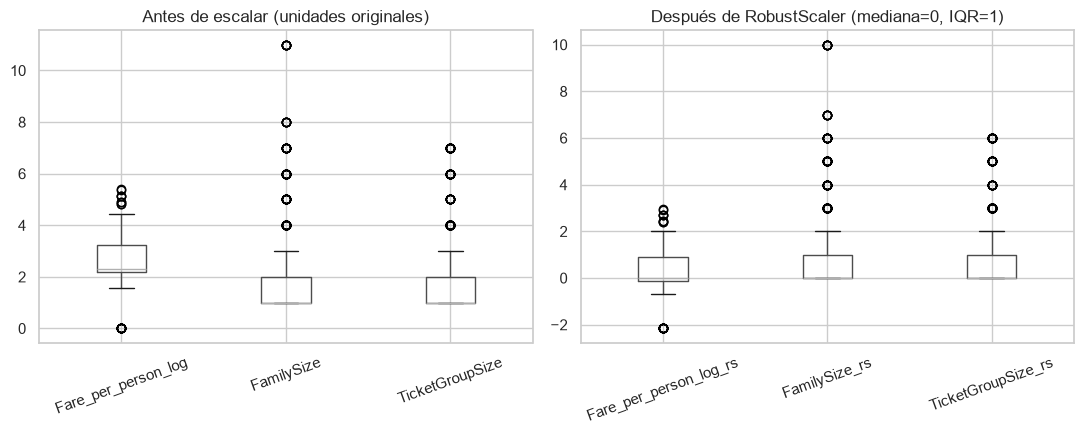

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

df[columnas_numericas_a_escalar].boxplot(ax=axes[0])
axes[0].set_title("Antes de escalar (unidades originales)")
axes[0].tick_params(axis="x", rotation=20)

numericas_escaladas.boxplot(ax=axes[1])
axes[1].set_title("Después de RobustScaler (mediana=0, IQR=1)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(f"{RUTA_FIGURAS}/f4_titanic_escalado_robusto.png", dpi=150, bbox_inches="tight")
plt.show()

In [31]:
def atipicos_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (serie < q1 - 1.5 * iqr) | (serie > q3 + 1.5 * iqr)


fare_atipico = atipicos_iqr(df["Fare"])
filas = []
for col in ["Fare", "Fare_per_person_log", "FamilySize", "TicketGroupSize"]:
    a = atipicos_iqr(df[col])
    filas.append({"variable": col, "atipicos_IQR": int(a.sum()), "pct": round(a.mean() * 100, 2), "se_escala": col in columnas_numericas_a_escalar})
diagnostico_atipicos = pd.DataFrame(filas)
persisten = int((fare_atipico & atipicos_iqr(df["Fare_per_person_log"])).sum())

z_estandar = StandardScaler().fit_transform(df[columnas_numericas_a_escalar])
comparacion_extremos = pd.DataFrame({
    "max_abs_StandardScaler": np.abs(z_estandar).max(axis=0),
    "max_RobustScaler": numericas_escaladas.max().values,
}, index=columnas_numericas_a_escalar).round(2)

print(diagnostico_atipicos.to_string(index=False))
print(f"\nDe los {int(fare_atipico.sum())} atípicos de Fare, siguen siéndolo en Fare_per_person_log: {persisten}")
print("\nMagnitud de los extremos según el escalador:")
print(comparacion_extremos.to_string())

           variable  atipicos_IQR   pct  se_escala
               Fare           116 13.02      False
Fare_per_person_log            24  2.69       True
         FamilySize            91 10.21       True
    TicketGroupSize            93 10.44       True

De los 116 atípicos de Fare, siguen siéndolo en Fare_per_person_log: 9

Magnitud de los extremos según el escalador:
                     max_abs_StandardScaler  max_RobustScaler
Fare_per_person_log                    3.67              2.95
FamilySize                             5.64             10.00
TicketGroupSize                        3.83              6.00


**Diagnóstico del escalado (precisa la justificación de IV.2).** Dividir `Fare` por el tamaño del ticket y aplicar `log1p` absorbió la mayor parte de los atípicos por tarifa de grupo: `Fare_per_person_log` conserva pocos atípicos (24, el 2.69 %) y solo 9 de los 116 atípicos originales de `Fare`. Los extremos que quedan en las variables escaladas son sobre todo de `FamilySize` y `TicketGroupSize` (≈ 10 % de atípicos por IQR), grupos numerosos que son legítimos. Además, `RobustScaler` **no atenúa** los extremos: `FamilySize_rs` llega a 10.0, mientras que con `StandardScaler` el valor absoluto máximo sería 5.64 (ambos escaladores son afines y la correlación entre sus resultados es 1). Por lo tanto, `RobustScaler` no se elige para "reducir atípicos", sino porque su centro y su escala (mediana e IQR) no se desplazan con la cola derecha y describen al pasajero típico; esto es relevante para modelos basados en distancias o regularizados, y es indiferente para los basados en árboles.

El escalado deja las tres variables centradas en 0 (mediana) con un rango intercuartílico de 1, sin recortar ni eliminar los valores extremos de `Fare_per_person_log`/`TicketGroupSize`/`FamilySize`, que las Fases 2-3 ya habían determinado que eran comportamiento legítimo (grupos numerosos, tarifas compartidas) y no errores de dato.

**Mejoras logradas respecto del dataset de entrada de esta fase (equivalente a `titanic_prepared.csv`, 891 × 32, reconstruido en II.2):**
- Se resolvió la redundancia entre 6 columnas heredadas de la integración con `seaborn`-data y 8 columnas propias descartadas explícitamente en la sección VI (`Pclass`, `Age_clean`, `Sex_bin`, `Fare_log`, `FareBand`, `IsAlone`, `Age_registrada`, `Cabin_registrada`), eliminando duplicación de señal; el inventario de la sección VI.5 da destino a las 36 columnas (32 de entrada más 4 nuevas).
- Se incorporaron 2 variables derivadas conceptuales (tarifa por persona e interacción sexo × clase), que suman 4 columnas nuevas (`TicketGroupSize`, `Fare_per_person`, `Fare_per_person_log`, `Sex_Pclass`), 3 de las cuales llegan al set final. `Sex_Pclass` tiene mayor V de Cramér que sus insumos por separado, y la interacción está respaldada por el test de razón de verosimilitudes (no solo por la V, que crece por construcción). `Fare_per_person_log` **no** tiene mayor asociación marginal que `Fare_log`; se prefiere por interpretabilidad y menor dependencia del tamaño del grupo.
- El set final (891 × 29: 27 características más `PassengerId` y `Survived`) está codificado y escalado, no tiene valores faltantes y su matriz tiene rango completo (sin colinealidad exacta), lo que lo deja listo para una etapa de modelamiento una vez excluido `PassengerId` de las variables predictoras.

In [32]:
df_features.to_csv(RUTA_SALIDA, index=False)
print(f"Dataset de características exportado a {RUTA_SALIDA}")
print("Columnas finales:", list(df_features.columns))

Dataset de características exportado a titanic_features.csv
Columnas finales: ['PassengerId', 'Survived', 'Fare_per_person_log_rs', 'FamilySize_rs', 'TicketGroupSize_rs', 'Title_agrupado_Master', 'Title_agrupado_Miss', 'Title_agrupado_Mrs', 'Title_agrupado_Nobleza', 'Title_agrupado_Oficial_Profesional', 'Sex_Pclass_female_1', 'Sex_Pclass_female_2', 'Sex_Pclass_female_3', 'Sex_Pclass_male_1', 'Sex_Pclass_male_2', 'AgeGroup_Adolescente_13_17', 'AgeGroup_Adulto_36_60', 'AgeGroup_Mayor_60', 'AgeGroup_Nino_0_12', 'Embarked_clean_C', 'Embarked_clean_Q', 'Deck_combinado_A', 'Deck_combinado_B', 'Deck_combinado_C', 'Deck_combinado_D', 'Deck_combinado_E', 'Deck_combinado_F', 'Deck_combinado_G', 'Deck_combinado_T']


---
## IX. Supuestos, limitaciones y cierre del notebook

**Resumen del pipeline implementado:** partiendo del dataset preparado de las Fases 2-3, reconstruido desde las fuentes originales (sección II.2), se diagnosticó qué transformación de escala faltaba (`RobustScaler`, por sus estadísticos insensibles a la cola de valores legítimos), se crearon dos variables derivadas motivadas por hallazgos concretos (`Fare_per_person_log`, a partir de la evidencia de tarifas compartidas por `Ticket`; `Sex_Pclass`, a partir de la interacción sexo-clase ya observada), se resolvió explícitamente la redundancia entre columnas propias y heredadas de la integración con `seaborn`-data (eliminando la redundancia exacta, incluida la de `Pclass` con `Sex_Pclass`), se clasificaron todas las variables candidatas en cuatro categorías de decisión con criterios y evidencia cuantitativa recalculada (V de Cramér, correlación de rango-biserial, información mutua), se dio destino documentado a cada una de las 36 columnas, y se exportó un dataset final codificado y escalado (`titanic_features.csv`).

**Supuestos asumidos:**
- Se asume que los 15 registros con `Fare` = 0 (todos varones, con `Ticket` `LINE` o numeración cercana entre sí) son un valor legítimo del dominio —posiblemente personal de la naviera u otro pasaje sin costo, hipótesis plausible mencionada en análisis públicos del dataset pero que este notebook no puede confirmar con la información disponible— y no un dato faltante mal codificado; por eso se conserva sin imputar (ya lo hereda `Fare_per_person`).
- Se asume que el criterio de selección aplicado (relevancia + redundancia + interpretabilidad + evidencia no paramétrica) es suficiente para una selección *preliminar*; una selección definitiva debería re-evaluarse con el desempeño real de un modelo entrenado, lo cual queda fuera del alcance de esta fase.
- Se asume que la codificación *one-hot* de variables con muchas categorías (`Deck_combinado`, 9 niveles) es adecuada a esta escala de datos (891 filas); en un dataset mucho más grande convendría revisar alternativas (p. ej. *target encoding*) para no inflar excesivamente la dimensionalidad.

**Limitaciones detectadas:**
- `Deck_combinado` tiene un nivel dominante "Desconocida" (77.1 % del total, categoría explícita heredada de Fases 2-3, **no imputada**), y la prueba de asociación sobre esta variable no es del todo confiable (27.8 % de celdas con frecuencia esperada < 5, sobre el 20 % de la regla de Cochran). Además, sus categorías `T` (1 caso) y `G` (4 casos) generan indicadoras casi vacías, igual que `Nobleza` en `Title_agrupado` (5 casos).
- Persiste **redundancia parcial** entre `Title_agrupado` y `Sex_Pclass` (el sexo queda explicado en gran medida por el título; R² ≈ 0.99). No hay colinealidad exacta (rango completo verificado), pero un modelo lineal sin regularización debería vigilarla.
- La información mutua combina un estimador exacto (discretas) y uno de vecinos (continuas), no estrictamente comparables; su ranking se usa solo como orden aproximado, y la decisión sobre `Age_clean` (descartada por imputación e interpretabilidad, aunque su información mutua supera a la de `AgeGroup`) debe revalidarse con el desempeño de un modelo.
- La evidencia de relevancia usada en esta fase (V de Cramér, rango-biserial, información mutua) es univariada: no descarta interacciones o efectos condicionales adicionales a `Sex_Pclass` que solo aparecerían al entrenar un modelo real.
- El `RobustScaler` (y la codificación *one-hot*) se ajustaron sobre los 891 registros, sin partición previa entrenamiento/prueba. Para esta fase exploratoria es aceptable, pero al modelar deberán ajustarse solo con los datos de entrenamiento (p. ej. dentro de un `Pipeline` con validación cruzada), o las estadísticas de mediana e IQR de la muestra completa filtrarán información de los datos de prueba. Lo mismo aplica a la imputación de `Age` y al conteo de `TicketGroupSize`, calculados con todos los registros.
- El tamaño de muestra (891 registros) limita la robustez de los conteos por celda en variables con más categorías (p. ej. `Sex_Pclass` x `Deck_combinado`), por lo que decisiones basadas en subgrupos muy pequeños deben tomarse con cautela.

**Observación final:** el dataset `titanic_features.csv` resultante queda en condiciones de alimentar una etapa de modelamiento predictivo (clasificación binaria de `Survived`) una vez excluido `PassengerId` de las variables predictoras, con un número acotado de características, cada una justificada individualmente, sin colinealidad exacta y sin fuga de información hacia el objetivo en la construcción de las variables (ver, no obstante, la limitación sobre el ajuste del escalador).